# Análisis Exploratorio de Datos (EDA)
## Dataset: `pen.src_vigente_stock_mensual desde 2022 pseudonimizado`

**Objetivo:** Entender el comportamiento del stock vigente de pensionados mensual de PEN desde 2022, identificando la composición demográfica, distribución de tipos de pensión, evolución temporal del padrón activo, distribución de montos de pensión, cobertura geográfica y calidad de los datos.

---

## 1. Importación de Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:,.4f}'.format)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga del Dataset

In [3]:
FILE_PATH = 'pen.src_vigente_stock_mensual desde 2022 pseudonimizado.csv'

df = pd.read_csv(
    FILE_PATH,
    sep=';',
    encoding='utf-8',
    low_memory=False,
    dtype={
        'PERIODO'           : 'Int64',
        'NUMERO_INSCRIPCION': 'Int64',
        'CODIGO_COMUNA'     : str,
        'AGENCIA_PENS'      : str,
        'ENTIDAD'           : str,
        'CCAF'              : str,
        'AGENCIA_VEND'      : str,
        'TIPO_PENSION'      : str,
        'FECHA_NACMTO'      : str,
        'FECHA_INICIO'      : str,
    }
)

# Parsear fechas desde formato timestamp de SQL
df['FECHA_NACMTO'] = pd.to_datetime(df['FECHA_NACMTO'], errors='coerce')
df['FECHA_INICIO'] = pd.to_datetime(df['FECHA_INICIO'], errors='coerce')

# Columna auxiliar de período como fecha
df['FECHA_PERIODO'] = pd.to_datetime(df['PERIODO'].astype(str), format='%Y%m', errors='coerce')

# Edad al período reportado
df['EDAD'] = (df['FECHA_PERIODO'] - df['FECHA_NACMTO']).dt.days // 365

# Antigüedad en meses desde inicio de pensión al período
df['ANTIGUEDAD_MESES'] = (
    (df['FECHA_PERIODO'].dt.year  - df['FECHA_INICIO'].dt.year) * 12 +
    (df['FECHA_PERIODO'].dt.month - df['FECHA_INICIO'].dt.month)
).clip(lower=0)

print(f'Dataset cargado exitosamente.')
print(f'  Filas:    {df.shape[0]:,}')
print(f'  Columnas: {df.shape[1]}')

Dataset cargado exitosamente.
  Filas:    363,202
  Columnas: 26


## 3. Vista General del Dataset

In [4]:
print('=== Primeras 5 filas ===')
df.head()

=== Primeras 5 filas ===


,PERIODO,NUMERO_INSCRIPCION,FECHA_NACMTO,POBLAC,COMUNA,CODIGO_COMUNA,AGENCIA_PENS,SEXO,ENTIDAD,NOMBRE_ENTIDAD,INDUSTRIA,PGU,APORTE_PGU,RENTA_PGU,CCAF,FECHA_INICIO,AGENCIA_VEND,TIPO_PENSION,NOMBRE_PENSION,APORTE,VALOR_PENSION,TIPO_SOLICITUD,ID_AFI,FECHA_PERIODO,EDAD,ANTIGUEDAD_MESES
0,202301,1635,1930-11-14,NaN,TOLTEN,91013,910,M,0,NaN,NaN,NaN,NaN,NaN,307,2009-04-01,910,1,NaN,NaN,"60,000.0000",NaN,AFI_01038477,2023-01-01,92,165.0000
1,202301,1774,1930-02-04,NaN,PUERTO SAAVEDRA,91009,910,M,0,NaN,NaN,NaN,NaN,NaN,307,2008-12-01,910,1,NaN,NaN,"60,000.0000",NaN,AFI_01038887,2023-01-01,92,169.0000
2,202301,18178,1939-06-25,NaN,VALPARAISO,52001,520,F,0,NaN,NaN,NaN,NaN,NaN,307,2009-04-01,510,1,NaN,NaN,"60,000.0000",NaN,AFI_01104470,2023-01-01,83,165.0000
3,202301,10277,1937-08-01,NaN,ARAUCO,81103,811,F,0,NaN,NaN,NaN,NaN,NaN,307,2009-03-01,811,1,NaN,NaN,"60,000.0000",NaN,AFI_01081184,2023-01-01,85,166.0000
4,202301,18481,1930-01-25,NaN,NIQUEN,83006,830,F,0,NaN,NaN,NaN,NaN,NaN,307,2008-10-01,810,1,NaN,NaN,"60,000.0000",NaN,AFI_01105168,2023-01-01,92,171.0000


In [5]:
print('=== Últimas 5 filas ===')
df.tail()

=== Últimas 5 filas ===


,PERIODO,NUMERO_INSCRIPCION,FECHA_NACMTO,POBLAC,COMUNA,CODIGO_COMUNA,AGENCIA_PENS,SEXO,ENTIDAD,NOMBRE_ENTIDAD,INDUSTRIA,PGU,APORTE_PGU,RENTA_PGU,CCAF,FECHA_INICIO,AGENCIA_VEND,TIPO_PENSION,NOMBRE_PENSION,APORTE,VALOR_PENSION,TIPO_SOLICITUD,ID_AFI,FECHA_PERIODO,EDAD,ANTIGUEDAD_MESES
363197,202406,56010,1971-04-09,NaN,SAN VICENTE,62005,620,M,0,NaN,NaN,NaN,NaN,NaN,302,2022-09-01,810,1,NaN,NaN,"212,858.0000",NaN,AFI_00300176,2024-06-01,53,21.0000
363198,202302,128220,1977-11-21,NaN,ANGOL,91201,912,M,0,NaN,NaN,NaN,NaN,NaN,307,2021-11-01,910,1,NaN,NaN,"164,356.0000",NaN,AFI_00295293,2023-02-01,45,15.0000
363199,202310,71456,1951-08-29,NaN,OLIVAR,61007,610,F,0,NaN,NaN,NaN,NaN,NaN,307,2009-02-01,610,2,NaN,NaN,"264,100.0000",NaN,AFI_01246585,2023-10-01,72,176.0000
363200,202308,136484,1990-06-18,NaN,LA UNION,101011,913,M,0,NaN,NaN,NaN,NaN,NaN,307,2023-03-01,1010,1,NaN,NaN,"193,917.0000",NaN,AFI_00527454,2023-08-01,33,5.0000
363201,202302,43011,1948-08-28,NaN,PUERTO MONTT,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-02-01,74,NaN


In [6]:
print('=== Tipos de datos y valores no nulos ===')
df.info(verbose=True, show_counts=True)

=== Tipos de datos y valores no nulos ===
<class 'pandas.DataFrame'>
RangeIndex: 363202 entries, 0 to 363201
Data columns (total 26 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   PERIODO             363202 non-null  Int64         
 1   NUMERO_INSCRIPCION  363202 non-null  Int64         
 2   FECHA_NACMTO        363202 non-null  datetime64[us]
 3   POBLAC              0 non-null       float64       
 4   COMUNA              363202 non-null  str           
 5   CODIGO_COMUNA       363202 non-null  str           
 6   AGENCIA_PENS        363201 non-null  str           
 7   SEXO                363201 non-null  str           
 8   ENTIDAD             363201 non-null  str           
 9   NOMBRE_ENTIDAD      0 non-null       float64       
 10  INDUSTRIA           0 non-null       float64       
 11  PGU                 0 non-null       float64       
 12  APORTE_PGU          0 non-null       float64       
 13

In [7]:
# Clasificación de columnas por tipo
col_numericas   = df.select_dtypes(include=['number']).columns.tolist()
col_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
col_fechas      = df.select_dtypes(include=['datetime']).columns.tolist()

print(f'Columnas numéricas   ({len(col_numericas)}): {col_numericas}')
print(f'Columnas categóricas ({len(col_categoricas)}): {col_categoricas}')
print(f'Columnas de fechas   ({len(col_fechas)}): {col_fechas}')

Columnas numéricas   (14): ['PERIODO', 'NUMERO_INSCRIPCION', 'POBLAC', 'NOMBRE_ENTIDAD', 'INDUSTRIA', 'PGU', 'APORTE_PGU', 'RENTA_PGU', 'NOMBRE_PENSION', 'APORTE', 'VALOR_PENSION', 'TIPO_SOLICITUD', 'EDAD', 'ANTIGUEDAD_MESES']
Columnas categóricas (9): ['COMUNA', 'CODIGO_COMUNA', 'AGENCIA_PENS', 'SEXO', 'ENTIDAD', 'CCAF', 'AGENCIA_VEND', 'TIPO_PENSION', 'ID_AFI']
Columnas de fechas   (3): ['FECHA_NACMTO', 'FECHA_INICIO', 'FECHA_PERIODO']


## 4. Análisis de Valores Nulos

In [8]:
nulos = pd.DataFrame({
    'Nulos'         : df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(4)
}).sort_values('Nulos', ascending=False)

print('=== Valores Nulos por Columna ===')
display(nulos)
print(f'\nColumnas sin valores nulos: {(nulos["Nulos"] == 0).sum()} de {len(df.columns)}')

=== Valores Nulos por Columna ===


,Nulos,Porcentaje (%)
NOMBRE_ENTIDAD,363202,100.0000
POBLAC,363202,100.0000
RENTA_PGU,363202,100.0000
NOMBRE_PENSION,363202,100.0000
TIPO_SOLICITUD,363202,100.0000
APORTE,363202,100.0000
PGU,363202,100.0000
APORTE_PGU,363202,100.0000
INDUSTRIA,363202,100.0000
ENTIDAD,1,0.0003



Columnas sin valores nulos: 7 de 26


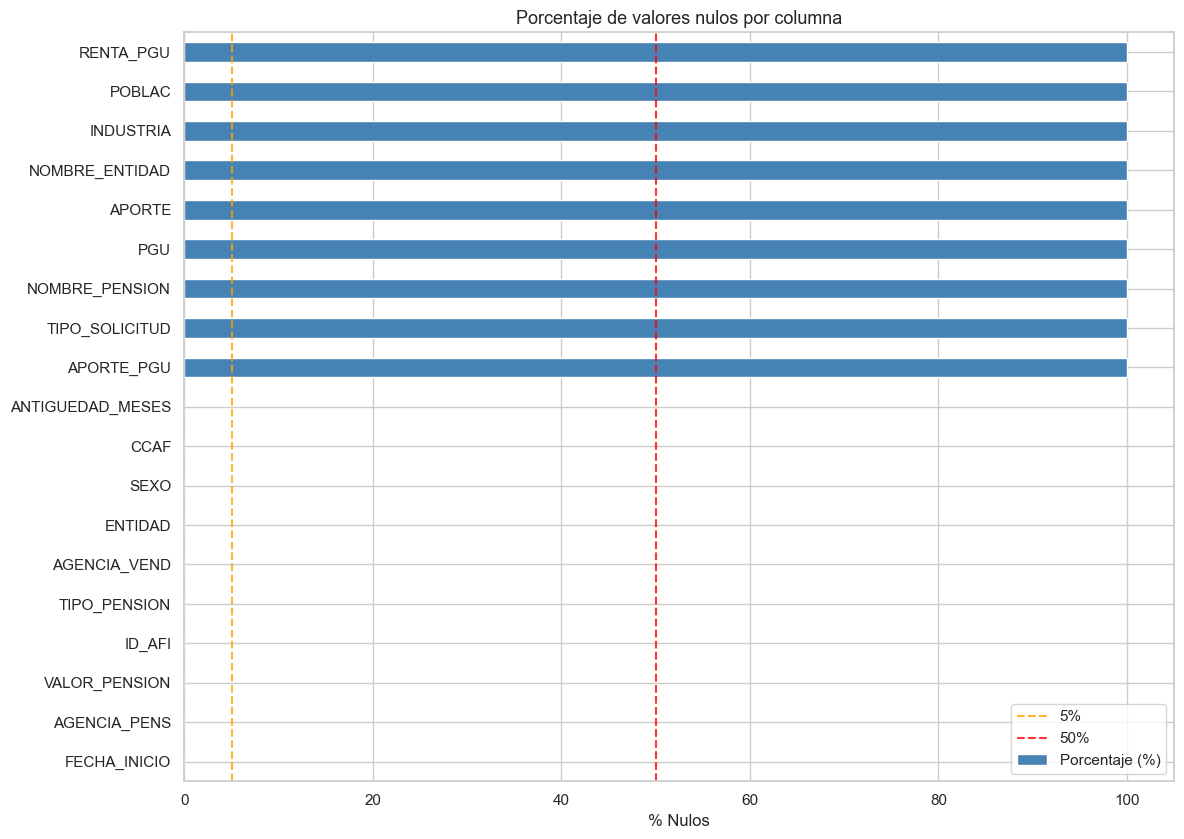

In [9]:
cols_con_nulos = nulos[nulos['Nulos'] > 0].index.tolist()

if cols_con_nulos:
    fig, ax = plt.subplots(figsize=(12, max(4, len(cols_con_nulos) * 0.45)))
    nulos.loc[cols_con_nulos, 'Porcentaje (%)'].sort_values().plot(
        kind='barh', ax=ax, color='steelblue', edgecolor='white'
    )
    ax.set_title('Porcentaje de valores nulos por columna', fontsize=13)
    ax.set_xlabel('% Nulos')
    ax.axvline(5,  color='orange', linestyle='--', alpha=0.8, label='5%')
    ax.axvline(50, color='red',    linestyle='--', alpha=0.8, label='50%')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No hay valores nulos en el dataset.')

## 5. Estadísticas Descriptivas

In [10]:
print('=== Variables Numéricas — Estadísticas Descriptivas ===')
df[col_numericas].describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', '50%'])

=== Variables Numéricas — Estadísticas Descriptivas ===


,count,mean,std,min,25%,50%,75%,max
PERIODO,363202.000000,202336.904263,45.168693,202301.000000,202305.000000,202309.000000,202402.000000,202406.000000
NUMERO_INSCRIPCION,363202.000000,70641.279018,44661.524239,1.000000,28840.000000,69928.000000,113653.750000,148728.000000
POBLAC,0.000000,nan,nan,nan,nan,nan,nan,nan
NOMBRE_ENTIDAD,0.000000,nan,nan,nan,nan,nan,nan,nan
INDUSTRIA,0.000000,nan,nan,nan,nan,nan,nan,nan
PGU,0.000000,nan,nan,nan,nan,nan,nan,nan
APORTE_PGU,0.000000,nan,nan,nan,nan,nan,nan,nan
RENTA_PGU,0.000000,nan,nan,nan,nan,nan,nan,nan
NOMBRE_PENSION,0.000000,nan,nan,nan,nan,nan,nan,nan
APORTE,0.000000,nan,nan,nan,nan,nan,nan,nan


In [11]:
# Asimetría, curtosis, ceros y negativos
stats_extra = pd.DataFrame({
    'Skewness' : df[col_numericas].skew(),
    'Kurtosis' : df[col_numericas].kurt(),
    'Ceros'    : (df[col_numericas] == 0).sum(),
    'Negativos': (df[col_numericas] < 0).sum()
})
print('=== Asimetría, Curtosis, Ceros y Negativos ===')
display(stats_extra)

=== Asimetría, Curtosis, Ceros y Negativos ===


,Skewness,Kurtosis,Ceros,Negativos
PERIODO,0.7898,-1.3559,0,0
NUMERO_INSCRIPCION,0.0032,-1.4095,0,0
POBLAC,<NA>,<NA>,0,0
NOMBRE_ENTIDAD,<NA>,<NA>,0,0
INDUSTRIA,<NA>,<NA>,0,0
PGU,<NA>,<NA>,0,0
APORTE_PGU,<NA>,<NA>,0,0
RENTA_PGU,<NA>,<NA>,0,0
NOMBRE_PENSION,<NA>,<NA>,0,0
APORTE,<NA>,<NA>,0,0


## 6. Análisis de Variables Categóricas

In [12]:
print('=== Cardinalidad de Variables Categóricas ===')
cardinalidad = pd.DataFrame({
    'Valores únicos'     : df[col_categoricas].nunique(),
    'Valor más frecuente': [df[c].mode()[0] if not df[c].dropna().empty else 'N/A' for c in col_categoricas],
    'Frecuencia moda'    : [df[c].value_counts().iloc[0] if not df[c].value_counts().empty else 0 for c in col_categoricas],
    '% Moda'             : [(df[c].value_counts().iloc[0] / len(df) * 100).round(2) if not df[c].value_counts().empty else 0 for c in col_categoricas]
}).sort_values('Valores únicos', ascending=False)
display(cardinalidad)

=== Cardinalidad de Variables Categóricas ===


,Valores únicos,Valor más frecuente,Frecuencia moda,% Moda
ID_AFI,38987,AFI_00000023,18,0.0000
CODIGO_COMUNA,415,82001,10618,2.9200
COMUNA,309,LOS ANGELES,11257,3.1000
AGENCIA_VEND,46,910,64220,17.6800
AGENCIA_PENS,45,910,52198,14.3700
CCAF,8,307,145784,40.1400
TIPO_PENSION,8,1,130653,35.9700
SEXO,2,F,213712,58.8400
ENTIDAD,1,0,363201,100.0000


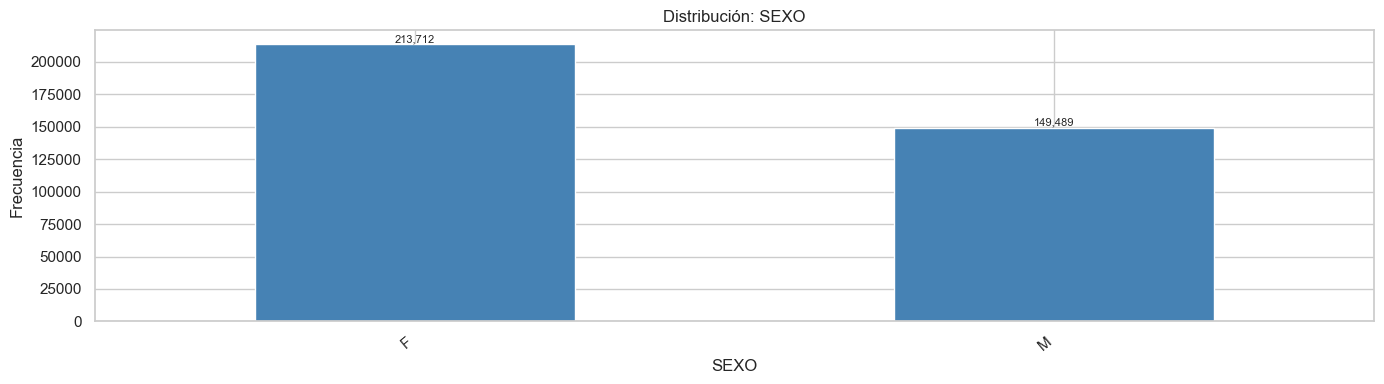

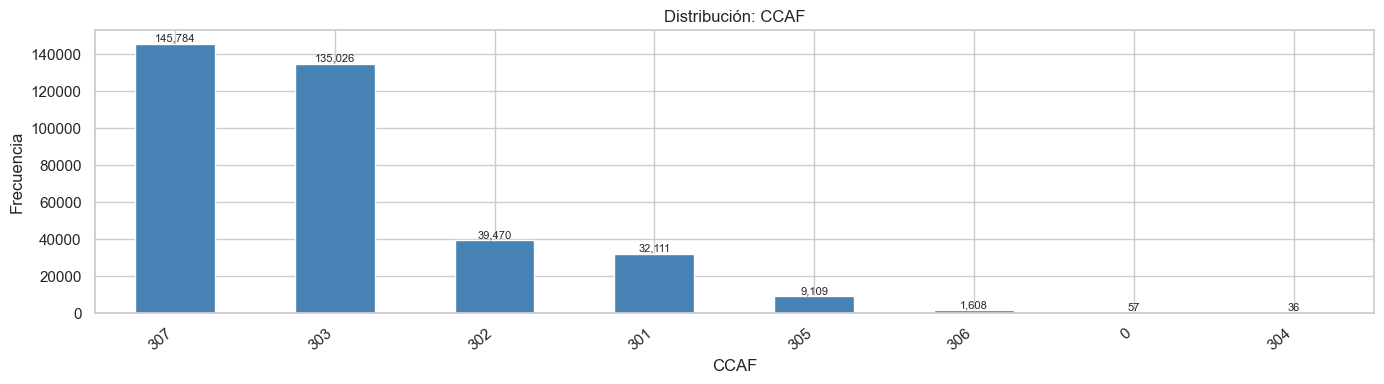

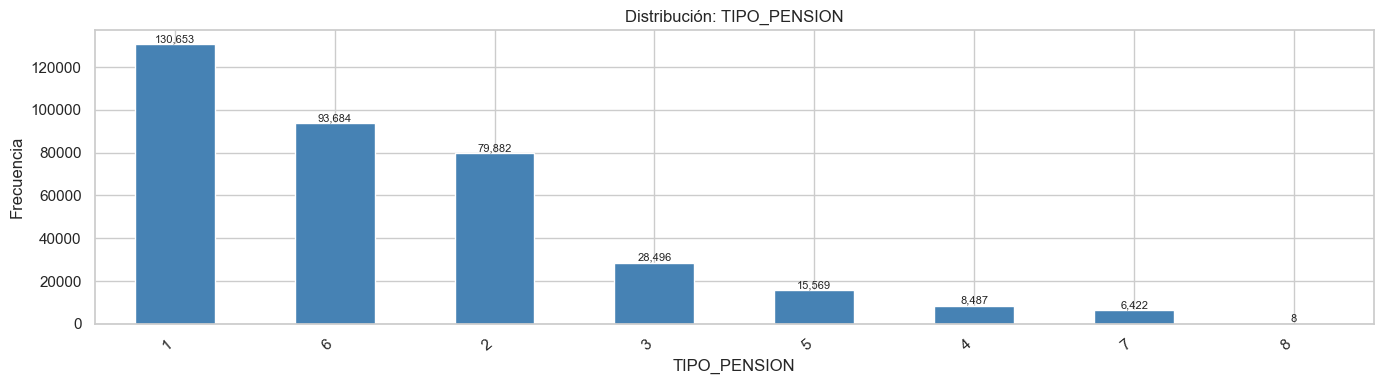

In [13]:
# Distribución de variables categóricas de baja cardinalidad (hasta 40 valores únicos)
cat_baja_card = [c for c in col_categoricas if 1 < df[c].nunique() <= 40]

for col in cat_baja_card:
    vc = df[col].value_counts().head(30)
    fig, ax = plt.subplots(figsize=(14, 4))
    vc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribución: {col}', fontsize=12)
    ax.set_ylabel('Frecuencia')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

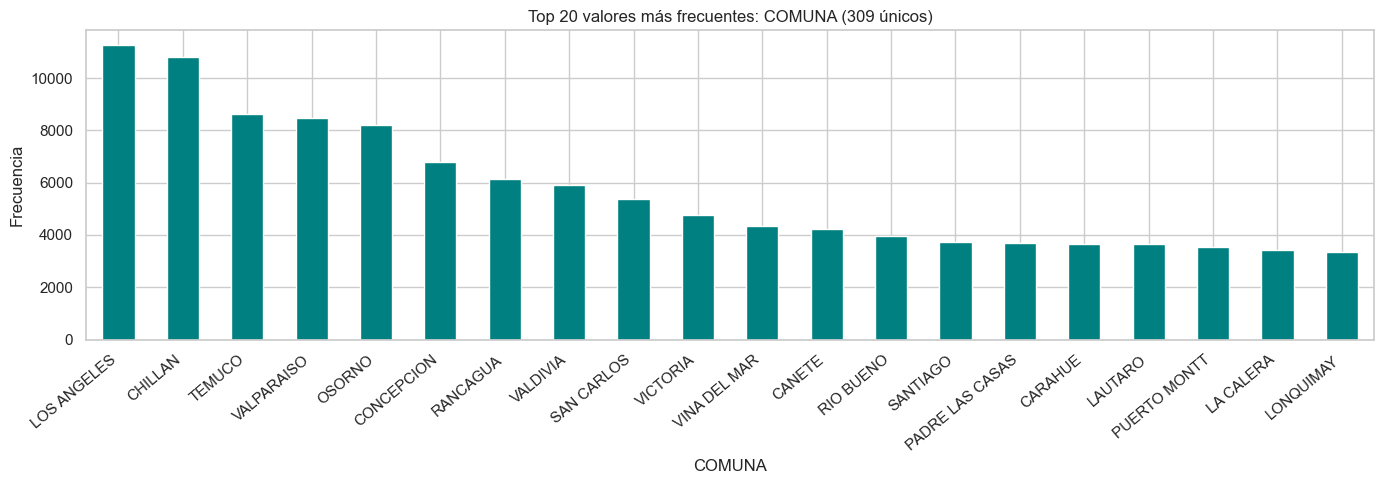

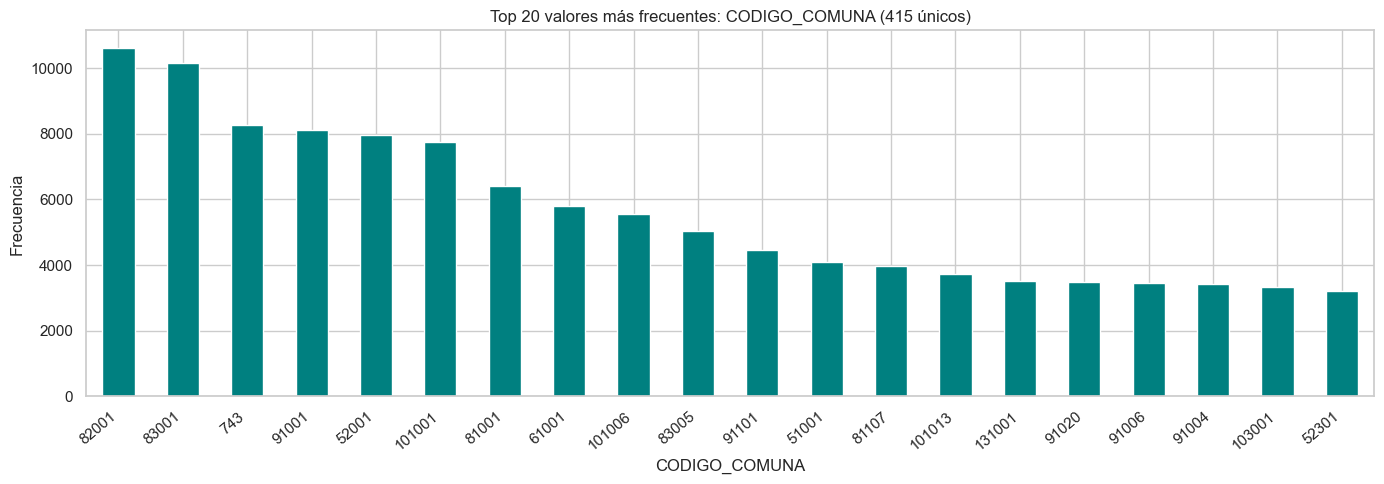

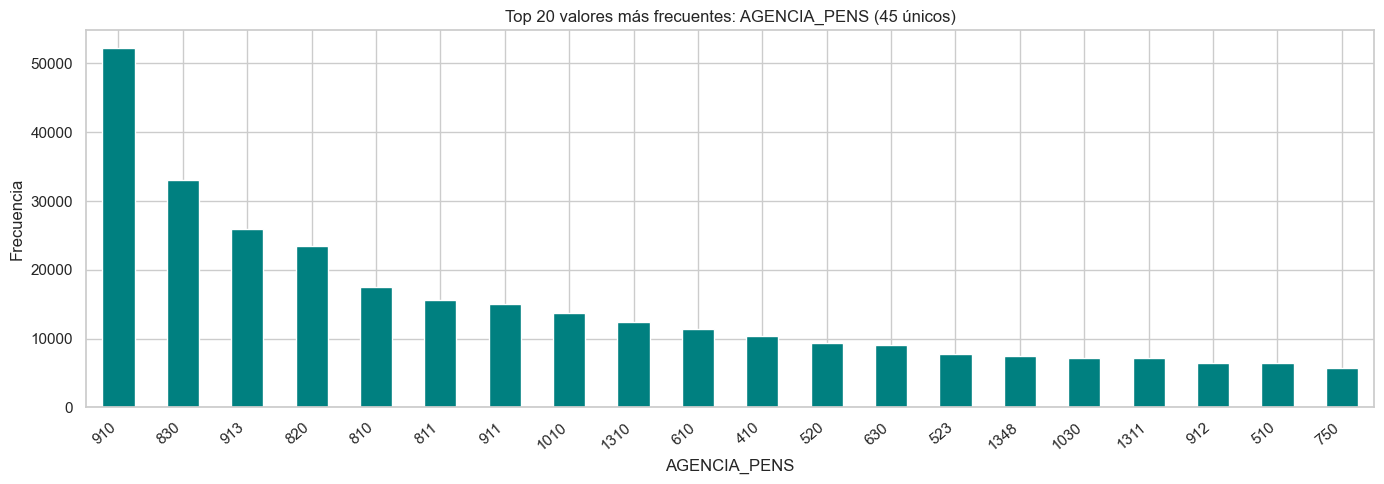

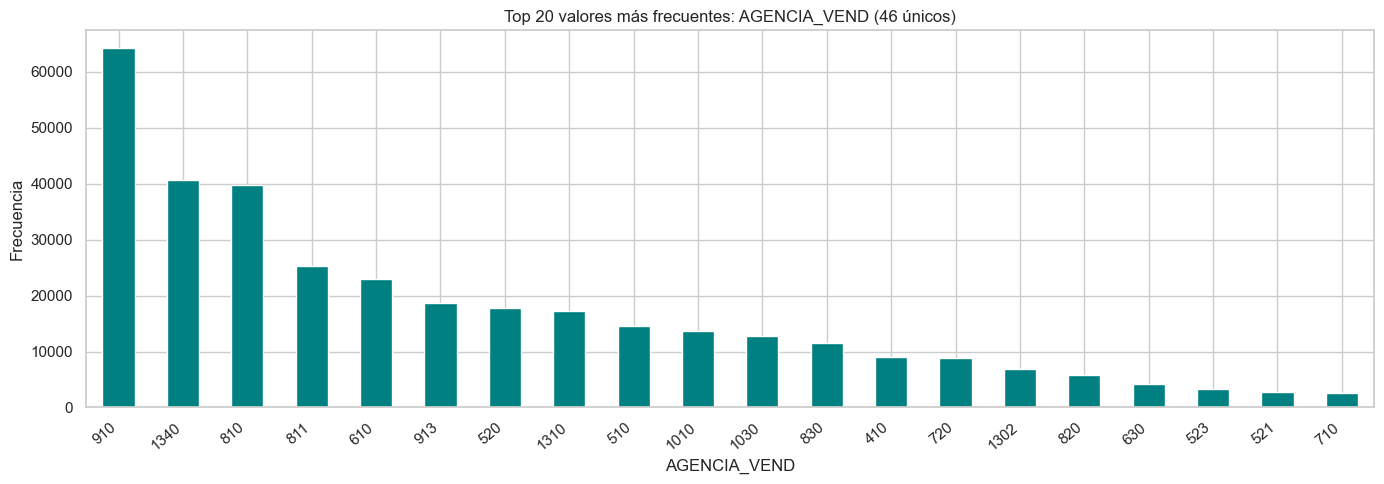

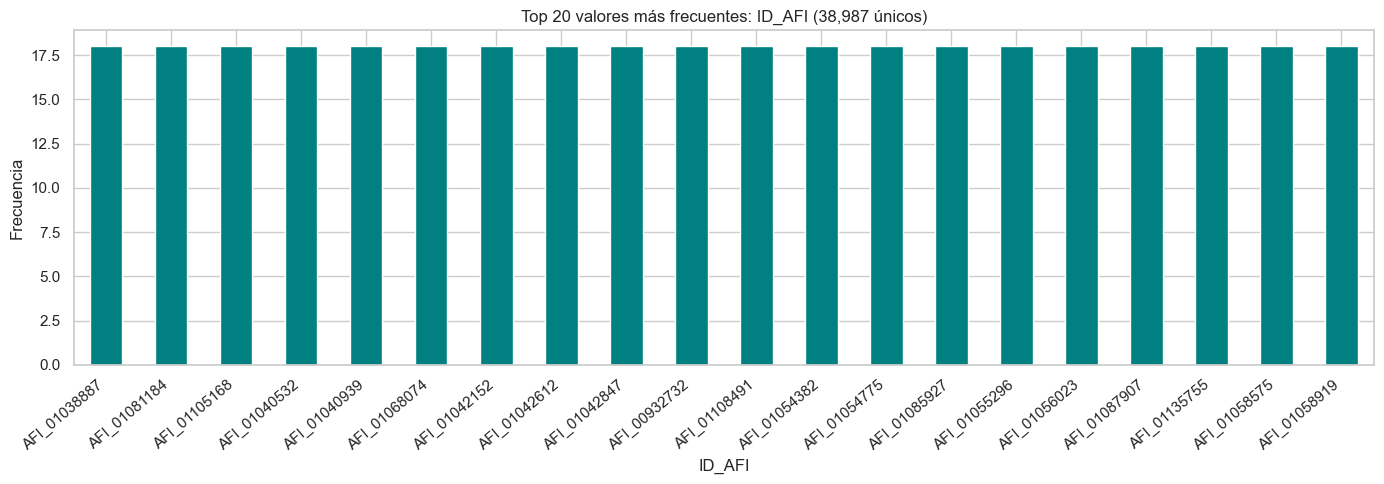

In [14]:
# Top 20 para variables de alta cardinalidad
cat_alta_card = [c for c in col_categoricas if df[c].nunique() > 40]

for col in cat_alta_card:
    fig, ax = plt.subplots(figsize=(14, 5))
    df[col].value_counts().head(20).plot(kind='bar', ax=ax, color='teal', edgecolor='white')
    ax.set_title(f'Top 20 valores más frecuentes: {col} ({df[col].nunique():,} únicos)', fontsize=12)
    ax.set_ylabel('Frecuencia')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Análisis del Monto de Pensión (VALOR_PENSION)

In [15]:
col_monto = 'VALOR_PENSION'

print(f'=== Estadísticas de {col_monto} ===')
print(df[col_monto].describe().to_string())
print(f'\nValores nulos : {df[col_monto].isnull().sum():,}')
print(f'Valores cero  : {(df[col_monto] == 0).sum():,}')
print(f'Valores únicos: {df[col_monto].nunique():,}')

=== Estadísticas de VALOR_PENSION ===
count     363,201.0000
mean      156,222.2078
std       152,168.8933
min             0.0000
25%        75,000.0000
50%       112,420.0000
75%       206,200.0000
max     4,364,315.0000

Valores nulos : 1
Valores cero  : 1,510
Valores únicos: 14,649


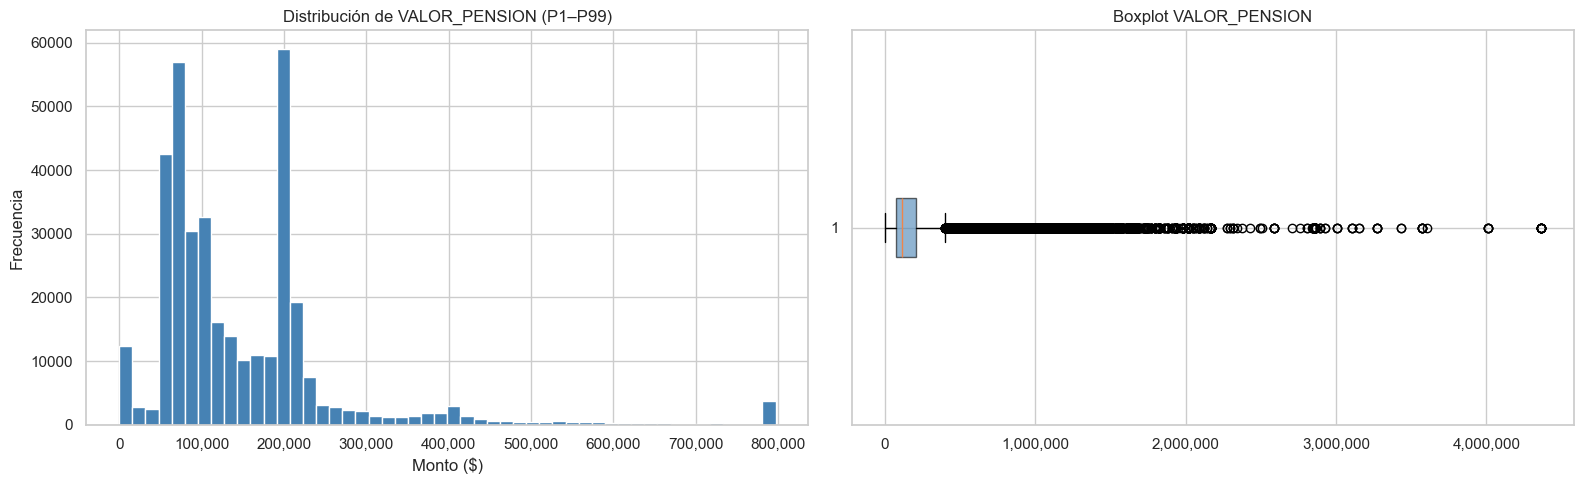

In [16]:
serie_monto = df[col_monto].dropna()
p1, p99     = serie_monto.quantile(0.01), serie_monto.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma (P1–P99 para eliminar extremos del eje)
serie_monto.clip(lower=p1, upper=p99).hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title(f'Distribución de {col_monto} (P1–P99)', fontsize=12)
axes[0].set_xlabel('Monto ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Boxplot
axes[1].boxplot(serie_monto, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title(f'Boxplot {col_monto}')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

In [17]:
# Percentiles del monto
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
tabla_pct = pd.DataFrame({
    'Percentil': [f'P{p}' for p in percentiles],
    'Valor ($)' : serie_monto.quantile([p/100 for p in percentiles]).values
})
print('=== Percentiles de VALOR_PENSION ===')
display(tabla_pct.style.format({'Valor ($)': '{:,.0f}'}))

=== Percentiles de VALOR_PENSION ===


,Percentil,Valor ($)
0,P1,1
1,P5,"49,245"
2,P10,"60,000"
3,P25,"75,000"
4,P50,"112,420"
5,P75,"206,200"
6,P90,"236,054"
7,P95,"379,000"
8,P99,"796,919"


## 8. Análisis de Tipo de Pensión

In [18]:
# Resumen por tipo de pensión
cols_tipo = [c for c in ['TIPO_PENSION', 'NOMBRE_PENSION'] if df[c].notna().any()]

for col_tipo in cols_tipo:
    resumen_tipo = df.groupby(col_tipo).agg(
        Registros        =(col_tipo, 'count'),
        Afiliados_Unicos =('ID_AFI', 'nunique'),
        Pension_Promedio =(col_monto, 'mean'),
        Pension_Mediana  =(col_monto, 'median'),
        Pension_Min      =(col_monto, 'min'),
        Pension_Max      =(col_monto, 'max'),
    ).reset_index().sort_values('Registros', ascending=False)

    print(f'=== Resumen por {col_tipo} ===')
    display(resumen_tipo.style.format({
        'Registros'        : '{:,}',
        'Afiliados_Unicos' : '{:,}',
        'Pension_Promedio' : '{:,.2f}',
        'Pension_Mediana'  : '{:,.2f}',
        'Pension_Min'      : '{:,.0f}',
        'Pension_Max'      : '{:,.0f}',
    }))

=== Resumen por TIPO_PENSION ===


,TIPO_PENSION,Registros,Afiliados_Unicos,Pension_Promedio,Pension_Mediana,Pension_Min,Pension_Max
0,1,"130,653","11,607","124,611.61","82,058.00",0,"2,506,200"
5,6,"93,684","10,120","158,286.14","164,056.00",0,"2,759,007"
1,2,"79,882","11,583","211,437.17","151,763.00",0,"4,364,315"
2,3,"28,496","2,628","166,337.83","125,476.00",0,"1,770,110"
4,5,"15,569","1,780","148,125.05","123,623.00",1,"2,014,029"
3,4,"8,487",644,"52,584.99","18,450.00",1,"766,319"
6,7,"6,422",713,"192,824.42","176,653.00",1,"1,241,019"
7,8,8,3,"1,193,720.62","1,235,883.00","526,533","1,832,800"


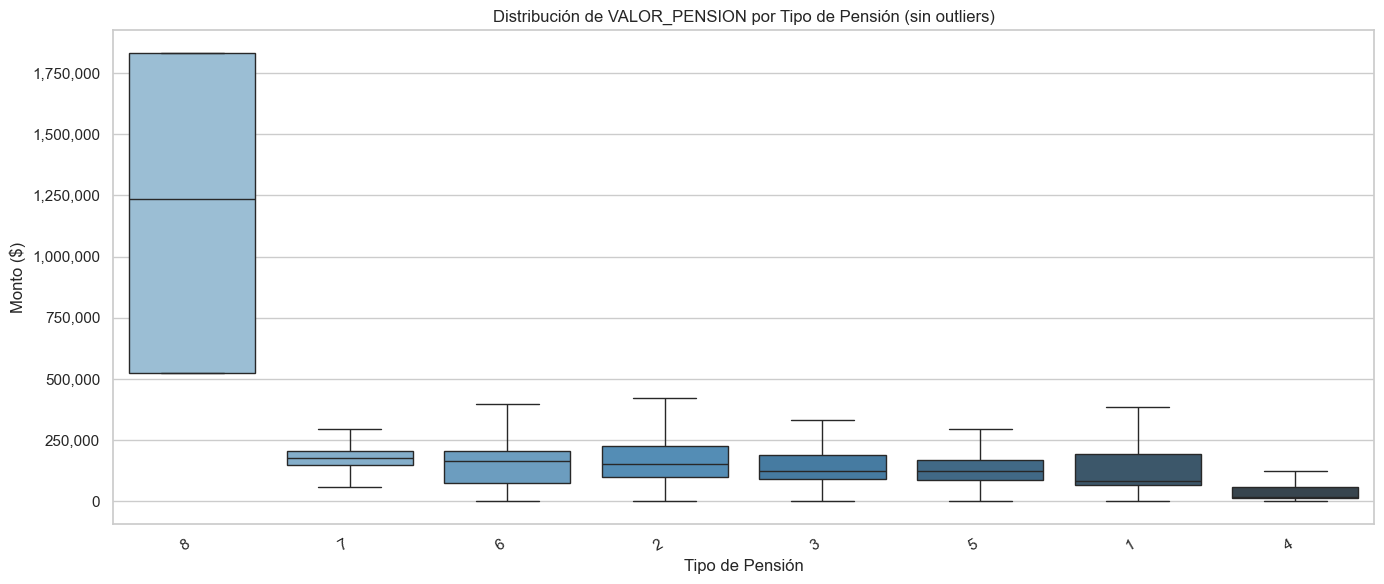

In [19]:
# Boxplot de VALOR_PENSION por TIPO_PENSION
if 'TIPO_PENSION' in df.columns and df['TIPO_PENSION'].notna().any():
    df_plot = df[df[col_monto].notna() & df['TIPO_PENSION'].notna()]
    tipos_orden = df_plot.groupby('TIPO_PENSION')[col_monto].median().sort_values(ascending=False).index.tolist()

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.boxplot(
        data=df_plot, x='TIPO_PENSION', y=col_monto,
        order=tipos_orden, palette='Blues_d', ax=ax,
        showfliers=False
    )
    ax.set_title('Distribución de VALOR_PENSION por Tipo de Pensión (sin outliers)', fontsize=12)
    ax.set_xlabel('Tipo de Pensión')
    ax.set_ylabel('Monto ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## 9. Análisis Demográfico

=== Distribución por Sexo ===


,Registros,Porcentaje (%)
SEXO,,
F,213712,58.8400
M,149489,41.1600


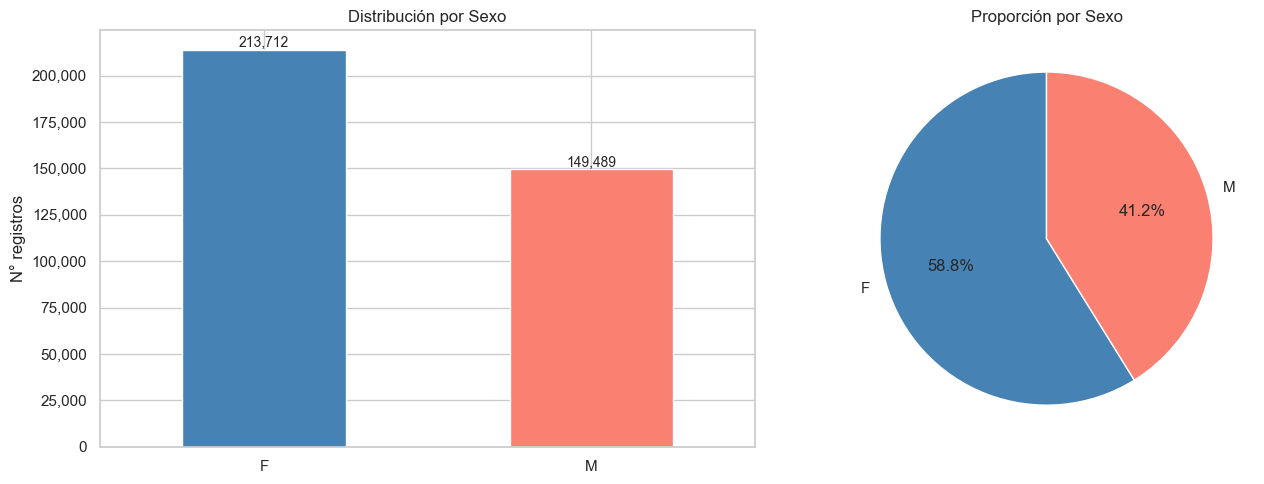

In [20]:
# Distribución por SEXO
sexo_counts = df['SEXO'].value_counts()
print('=== Distribución por Sexo ===')
display(pd.DataFrame({
    'Registros'     : sexo_counts,
    'Porcentaje (%)': (sexo_counts / len(df) * 100).round(2)
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
sexo_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title('Distribución por Sexo', fontsize=12)
axes[0].set_ylabel('N° registros')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)
plt.sca(axes[0]); plt.xticks(rotation=0)

# Pie
axes[1].pie(sexo_counts, labels=sexo_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Proporción por Sexo', fontsize=12)

plt.tight_layout()
plt.show()

=== Estadísticas de Edad ===
count   363,160.0000
mean         71.1461
std          15.2173
min          18.0000
25%          63.0000
50%          74.0000
75%          82.0000
max         113.0000


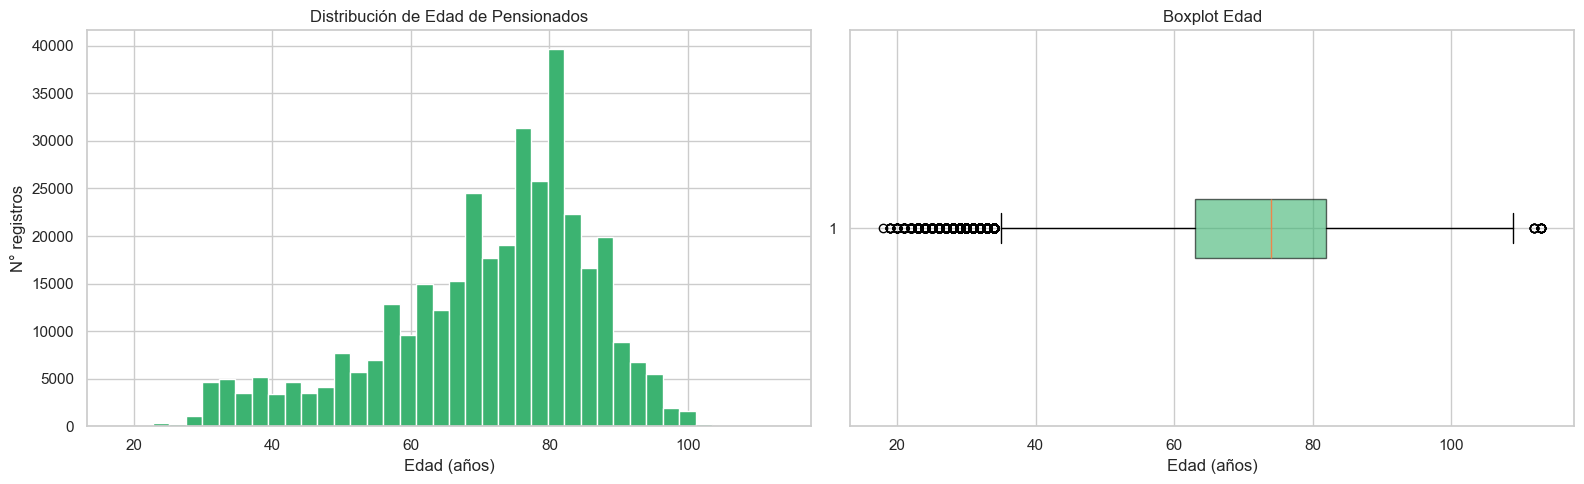

In [21]:
# Distribución de Edad
edad_valida = df['EDAD'].dropna()
edad_valida = edad_valida[(edad_valida >= 0) & (edad_valida <= 120)]

print(f'=== Estadísticas de Edad ===')
print(edad_valida.describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

edad_valida.hist(bins=40, ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('Distribución de Edad de Pensionados', fontsize=12)
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('N° registros')

axes[1].boxplot(edad_valida, vert=False, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.6))
axes[1].set_title('Boxplot Edad')
axes[1].set_xlabel('Edad (años)')

plt.tight_layout()
plt.show()

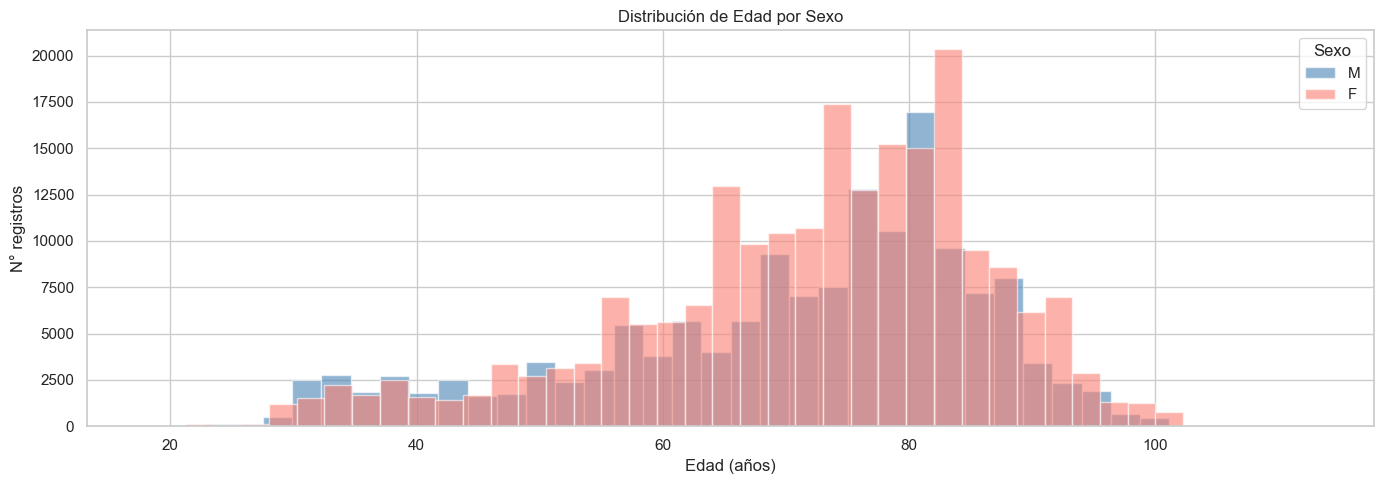


=== Estadísticas de Edad por Sexo ===


,count,mean,std,min,25%,50%,75%,max
SEXO,,,,,,,,
F,"213,688.0000",71.8008,14.6323,19.0000,64.0000,74.0000,82.0000,109.0000
M,"149,471.0000",70.2101,15.9702,18.0000,61.0000,74.0000,82.0000,113.0000


In [22]:
# Distribución de Edad por Sexo
df_edad = df[(df['EDAD'] >= 0) & (df['EDAD'] <= 120) & df['SEXO'].notna()]

fig, ax = plt.subplots(figsize=(14, 5))
for sexo, color in [('M', 'steelblue'), ('F', 'salmon')]:
    subset = df_edad[df_edad['SEXO'] == sexo]['EDAD']
    subset.hist(bins=40, ax=ax, alpha=0.6, color=color, edgecolor='white', label=sexo)
ax.set_title('Distribución de Edad por Sexo', fontsize=12)
ax.set_xlabel('Edad (años)')
ax.set_ylabel('N° registros')
ax.legend(title='Sexo')
plt.tight_layout()
plt.show()

print('\n=== Estadísticas de Edad por Sexo ===')
display(df_edad.groupby('SEXO')['EDAD'].describe())

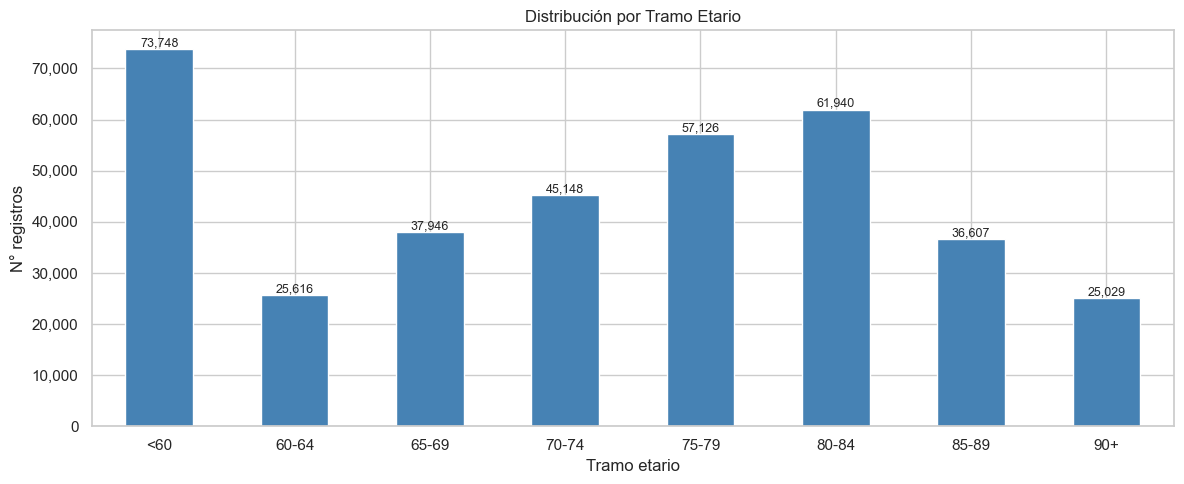

In [23]:
# Tramos etarios
bins_edad   = [0, 60, 65, 70, 75, 80, 85, 90, 120]
labels_edad = ['<60', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90+']
df['TRAMO_EDAD'] = pd.cut(df['EDAD'], bins=bins_edad, labels=labels_edad, right=False)

tramo_counts = df['TRAMO_EDAD'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
tramo_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribución por Tramo Etario', fontsize=12)
ax.set_ylabel('N° registros')
ax.set_xlabel('Tramo etario')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

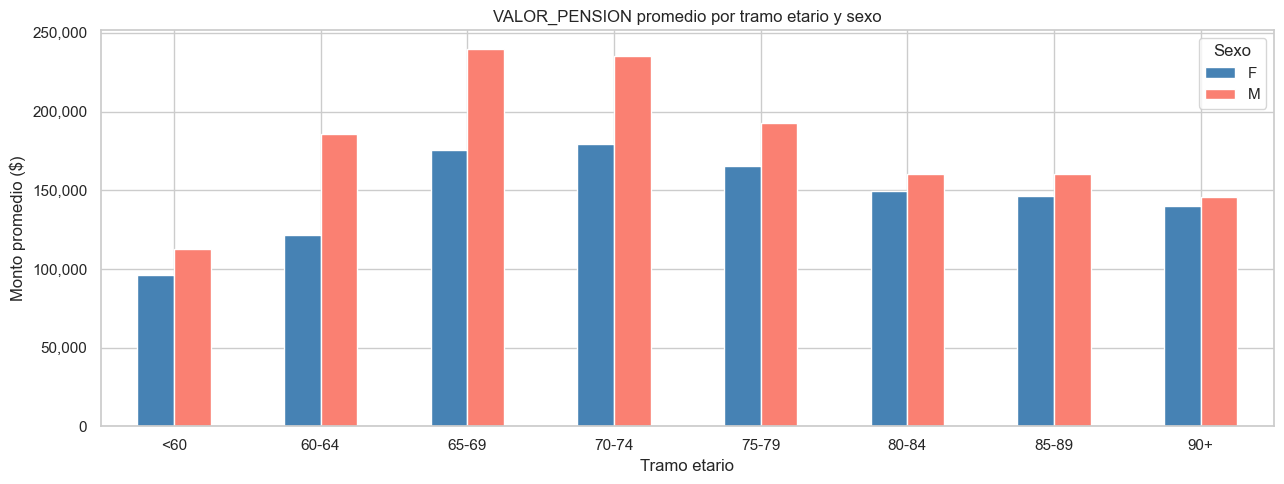

In [24]:
# VALOR_PENSION promedio por tramo etario y sexo
pension_edad_sexo = df.groupby(['TRAMO_EDAD', 'SEXO'])[col_monto].mean().unstack()

fig, ax = plt.subplots(figsize=(13, 5))
pension_edad_sexo.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='white')
ax.set_title('VALOR_PENSION promedio por tramo etario y sexo', fontsize=12)
ax.set_xlabel('Tramo etario')
ax.set_ylabel('Monto promedio ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Sexo')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Análisis Geográfico

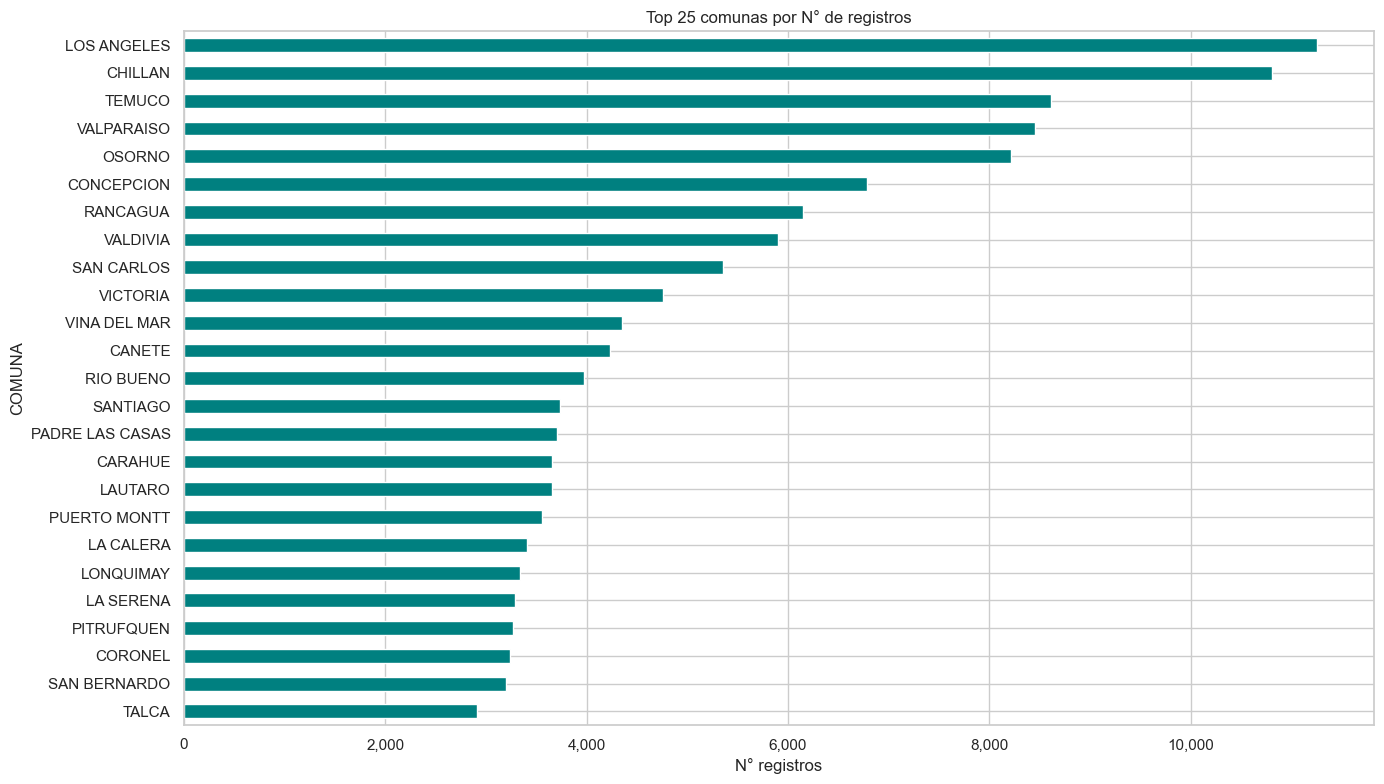


Total comunas únicas: 309


In [25]:
# Top comunas por número de pensionados activos
top_n = 25
top_comunas = df['COMUNA'].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(14, 8))
top_comunas.plot(kind='barh', ax=ax, color='teal', edgecolor='white')
ax.set_title(f'Top {top_n} comunas por N° de registros', fontsize=12)
ax.set_xlabel('N° registros')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'\nTotal comunas únicas: {df["COMUNA"].nunique():,}')

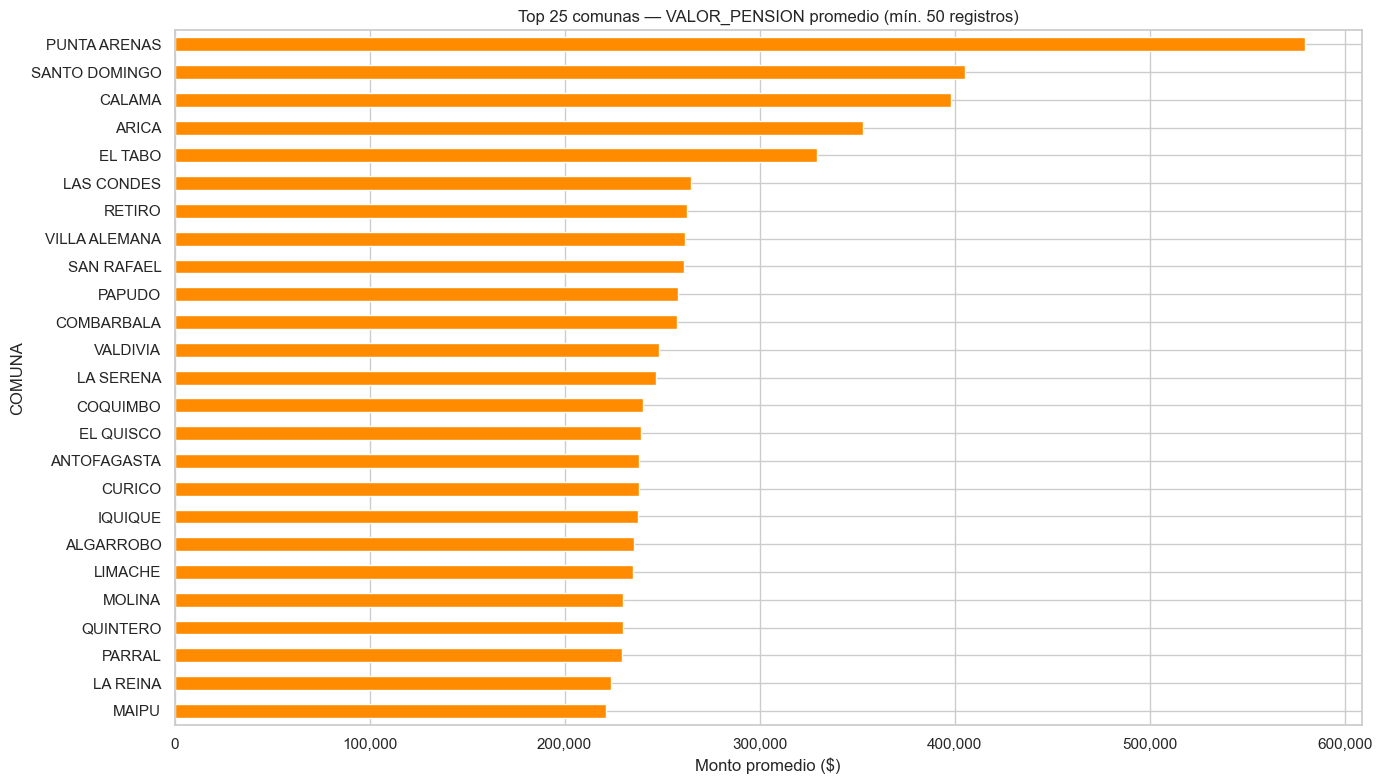

In [26]:
# VALOR_PENSION promedio por las top comunas
pension_comuna = df.groupby('COMUNA')[col_monto].agg(['mean', 'median', 'count'])
pension_comuna.columns = ['Promedio', 'Mediana', 'N_Registros']
pension_comuna = pension_comuna[pension_comuna['N_Registros'] >= 50].sort_values('Promedio', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
pension_comuna['Promedio'].head(25).plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Top 25 comunas — VALOR_PENSION promedio (mín. 50 registros)', fontsize=12)
ax.set_xlabel('Monto promedio ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [27]:
# Análisis de Agencias de Pensión
if 'AGENCIA_PENS' in df.columns:
    resumen_agencia = df.groupby('AGENCIA_PENS').agg(
        Registros        =('AGENCIA_PENS', 'count'),
        Afiliados_Unicos =('ID_AFI', 'nunique'),
        Pension_Promedio =(col_monto, 'mean'),
        Pension_Mediana  =(col_monto, 'median'),
    ).reset_index().sort_values('Registros', ascending=False)

    print('=== Resumen por Agencia de Pensión (top 20) ===')
    display(resumen_agencia.head(20).style.format({
        'Registros'        : '{:,}',
        'Afiliados_Unicos' : '{:,}',
        'Pension_Promedio' : '{:,.2f}',
        'Pension_Mediana'  : '{:,.2f}',
    }))

=== Resumen por Agencia de Pensión (top 20) ===


,AGENCIA_PENS,Registros,Afiliados_Unicos,Pension_Promedio,Pension_Mediana
41,910,"52,198","5,897","138,533.12","102,897.00"
40,830,"33,042","2,608","138,214.00","97,102.00"
44,913,"25,998","2,338","196,547.24","176,096.00"
39,820,"23,542","1,778","129,501.25","89,716.00"
37,810,"17,498","1,308","113,883.39","76,259.00"
38,811,"15,557","1,153","120,131.10","81,535.00"
42,911,"15,033","1,889","143,740.05","111,090.00"
0,1010,"13,793","1,444","196,970.05","193,917.00"
6,1310,"12,409","1,877","148,899.15","104,960.00"
29,610,"11,351","1,073","136,712.76","102,897.00"


## 11. Análisis Temporal

In [28]:
# Cobertura temporal
print(f'PERIODO:')
print(f'  Mínimo         : {df["PERIODO"].min()}')
print(f'  Máximo         : {df["PERIODO"].max()}')
print(f'  Períodos únicos: {df["PERIODO"].nunique()}')

print(f'\nFECHA_INICIO:')
print(f'  Mínimo: {df["FECHA_INICIO"].min()}')
print(f'  Máximo: {df["FECHA_INICIO"].max()}')
print(f'  Nulos : {df["FECHA_INICIO"].isnull().sum():,}')

PERIODO:
  Mínimo         : 202301
  Máximo         : 202406
  Períodos únicos: 18

FECHA_INICIO:
  Mínimo: 2000-03-01 00:00:00
  Máximo: 2024-08-01 00:00:00
  Nulos : 1


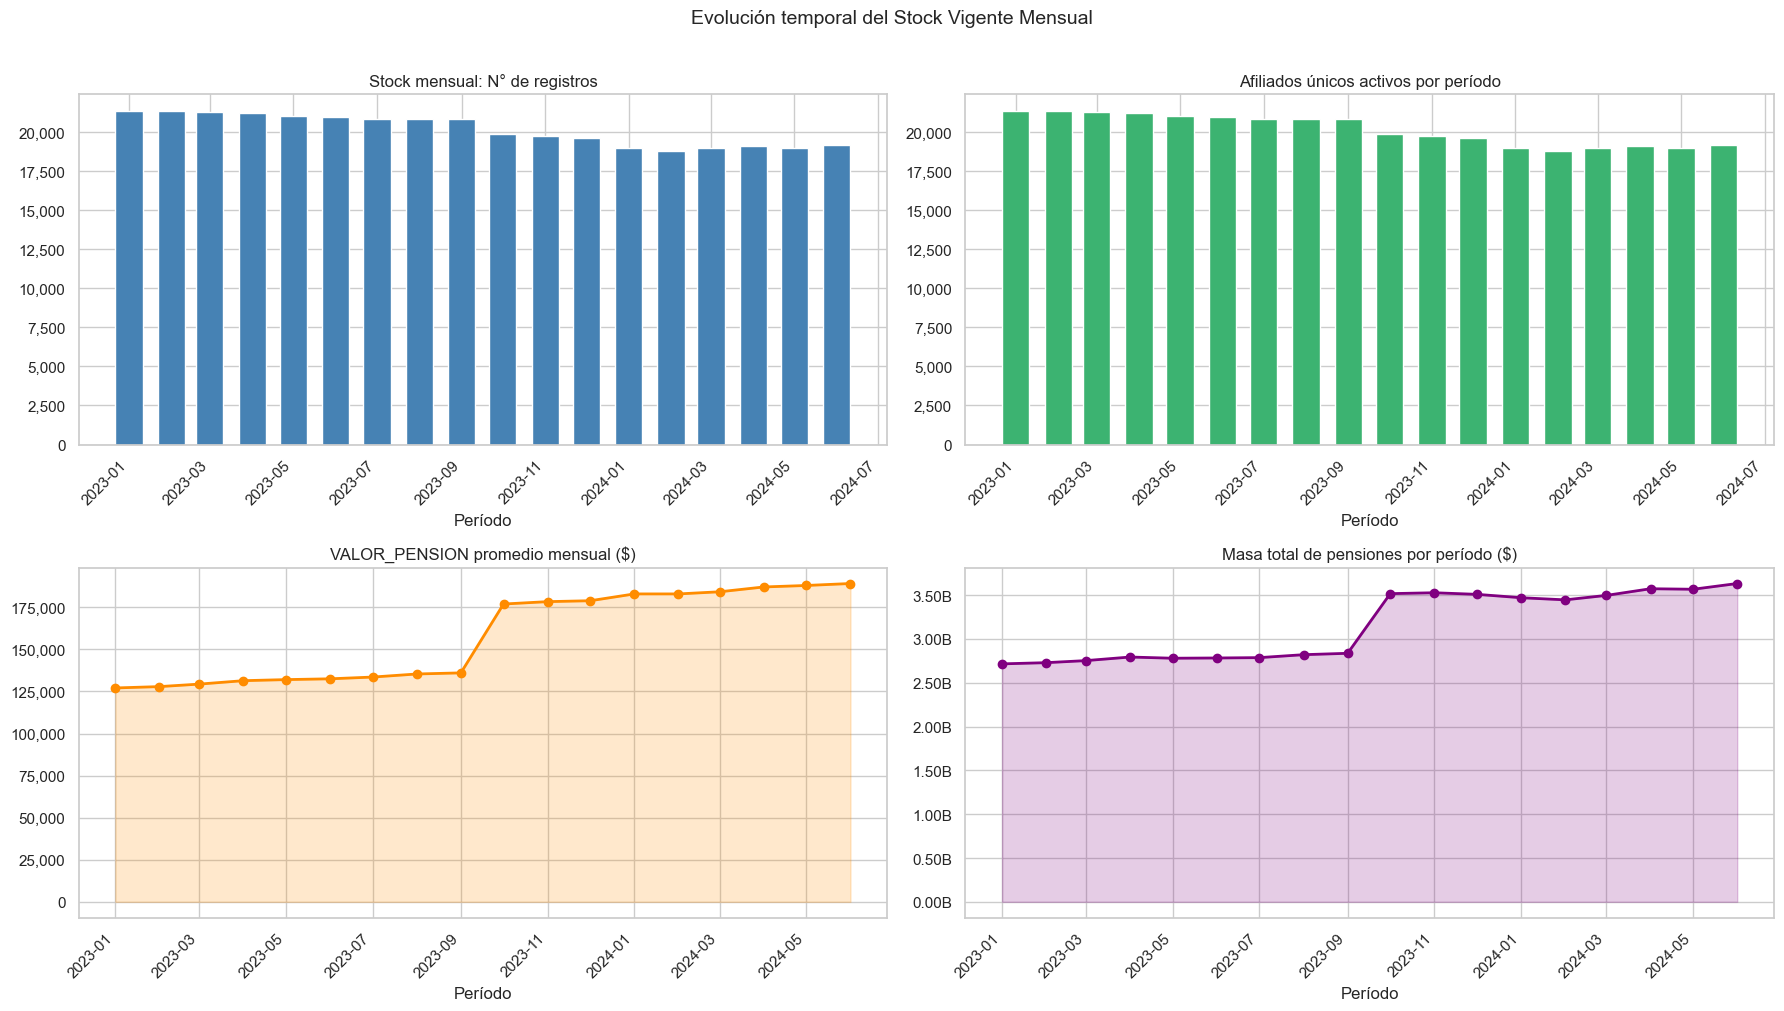

In [29]:
# Stock vigente (padrón activo) por período
stock_mensual = df.groupby('FECHA_PERIODO').agg(
    N_Registros      =('ID_AFI', 'count'),
    Afiliados_Unicos =('ID_AFI', 'nunique'),
    Pension_Promedio =(col_monto, 'mean'),
    Pension_Total    =(col_monto, 'sum'),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Stock total
axes[0, 0].bar(stock_mensual['FECHA_PERIODO'], stock_mensual['N_Registros'],
               color='steelblue', width=20)
axes[0, 0].set_title('Stock mensual: N° de registros', fontsize=12)
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.sca(axes[0, 0]); plt.xticks(rotation=45, ha='right')

# Afiliados únicos por mes
axes[0, 1].bar(stock_mensual['FECHA_PERIODO'], stock_mensual['Afiliados_Unicos'],
               color='mediumseagreen', width=20)
axes[0, 1].set_title('Afiliados únicos activos por período', fontsize=12)
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.sca(axes[0, 1]); plt.xticks(rotation=45, ha='right')

# Pensión promedio mensual
axes[1, 0].plot(stock_mensual['FECHA_PERIODO'], stock_mensual['Pension_Promedio'],
                marker='o', color='darkorange', linewidth=2)
axes[1, 0].fill_between(stock_mensual['FECHA_PERIODO'], stock_mensual['Pension_Promedio'],
                        alpha=0.2, color='darkorange')
axes[1, 0].set_title('VALOR_PENSION promedio mensual ($)', fontsize=12)
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.sca(axes[1, 0]); plt.xticks(rotation=45, ha='right')

# Masa total de pensiones
axes[1, 1].plot(stock_mensual['FECHA_PERIODO'], stock_mensual['Pension_Total'],
                marker='o', color='purple', linewidth=2)
axes[1, 1].fill_between(stock_mensual['FECHA_PERIODO'], stock_mensual['Pension_Total'],
                        alpha=0.2, color='purple')
axes[1, 1].set_title('Masa total de pensiones por período ($)', fontsize=12)
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:,.2f}B'))
plt.sca(axes[1, 1]); plt.xticks(rotation=45, ha='right')

for ax in axes.flatten():
    ax.set_xlabel('Período')

plt.suptitle('Evolución temporal del Stock Vigente Mensual', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

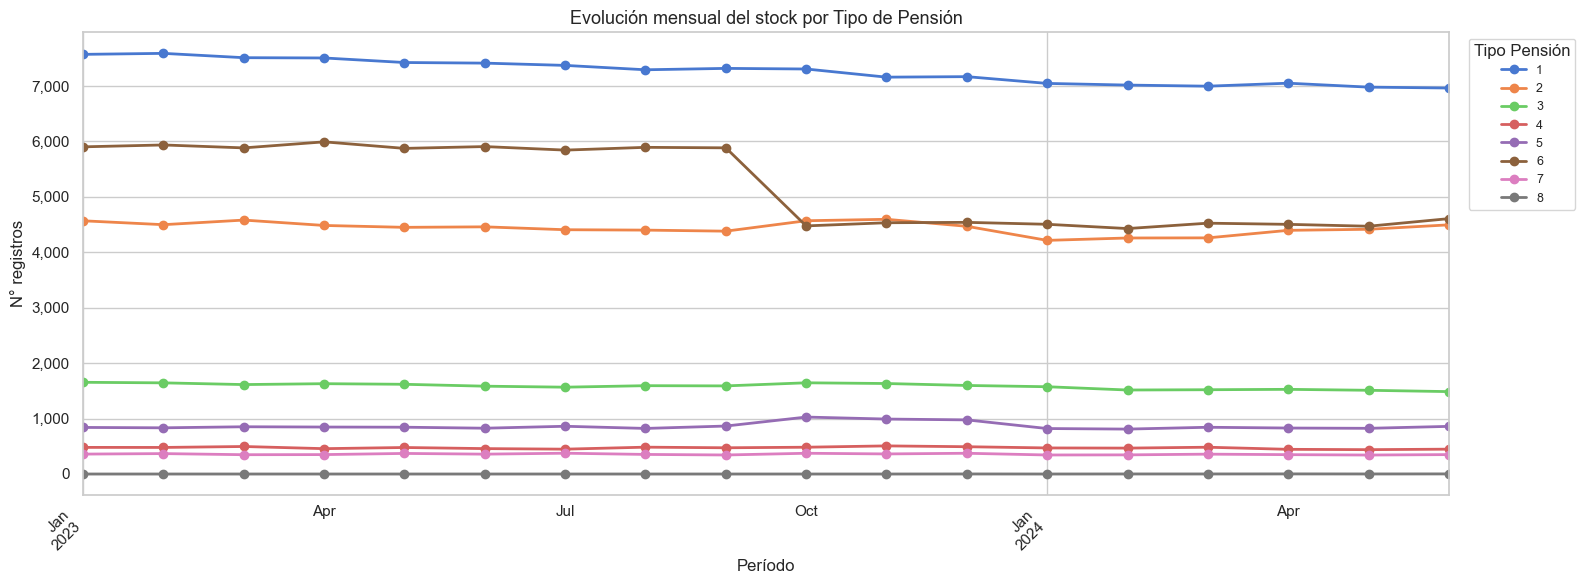

In [30]:
# Evolución del stock por TIPO_PENSION y período
if 'TIPO_PENSION' in df.columns and df['TIPO_PENSION'].notna().any():
    pivot_tipo = df.groupby(['FECHA_PERIODO', 'TIPO_PENSION']).size().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(16, 6))
    pivot_tipo.plot(ax=ax, marker='o', linewidth=2)
    ax.set_title('Evolución mensual del stock por Tipo de Pensión', fontsize=13)
    ax.set_xlabel('Período')
    ax.set_ylabel('N° registros')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(title='Tipo Pensión', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

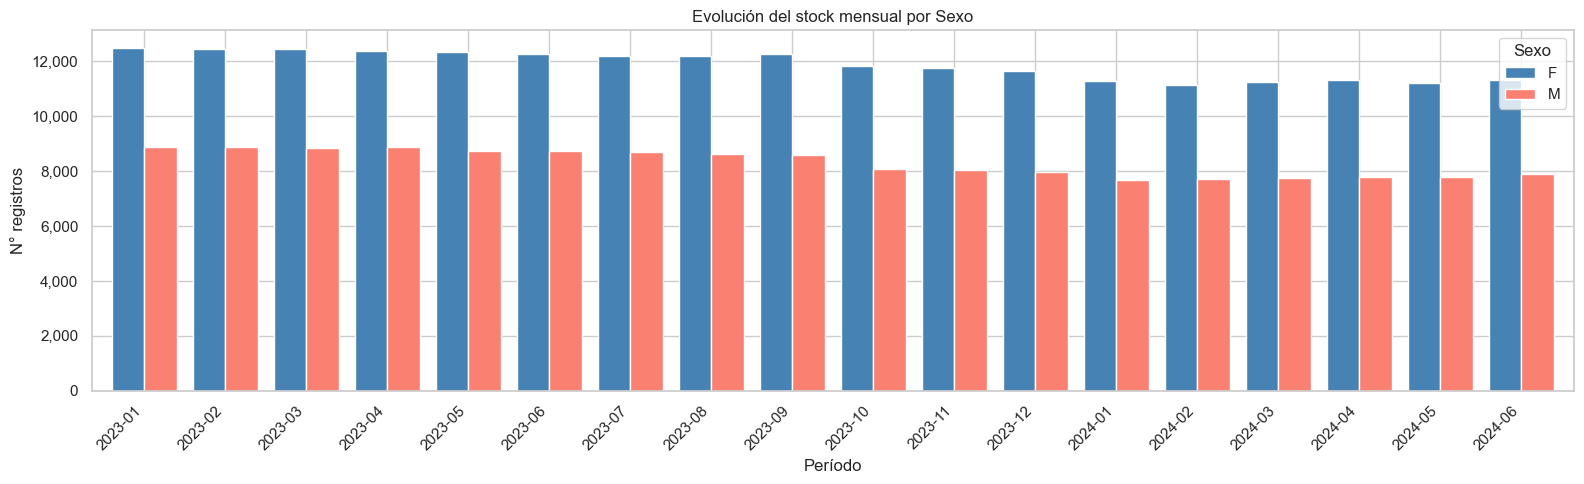

In [31]:
# Stock por período y sexo
pivot_sexo = df.groupby([df['FECHA_PERIODO'].dt.strftime('%Y-%m'), 'SEXO']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 5))
pivot_sexo.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='white', width=0.8)
ax.set_title('Evolución del stock mensual por Sexo', fontsize=12)
ax.set_xlabel('Período')
ax.set_ylabel('N° registros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Sexo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 12. Análisis de Antigüedad de Pensión

=== Antigüedad de Pensión (meses) ===
count   363,201.0000
mean        116.9553
std          66.1379
min           0.0000
25%          55.0000
50%         151.0000
75%         170.0000
max         285.0000


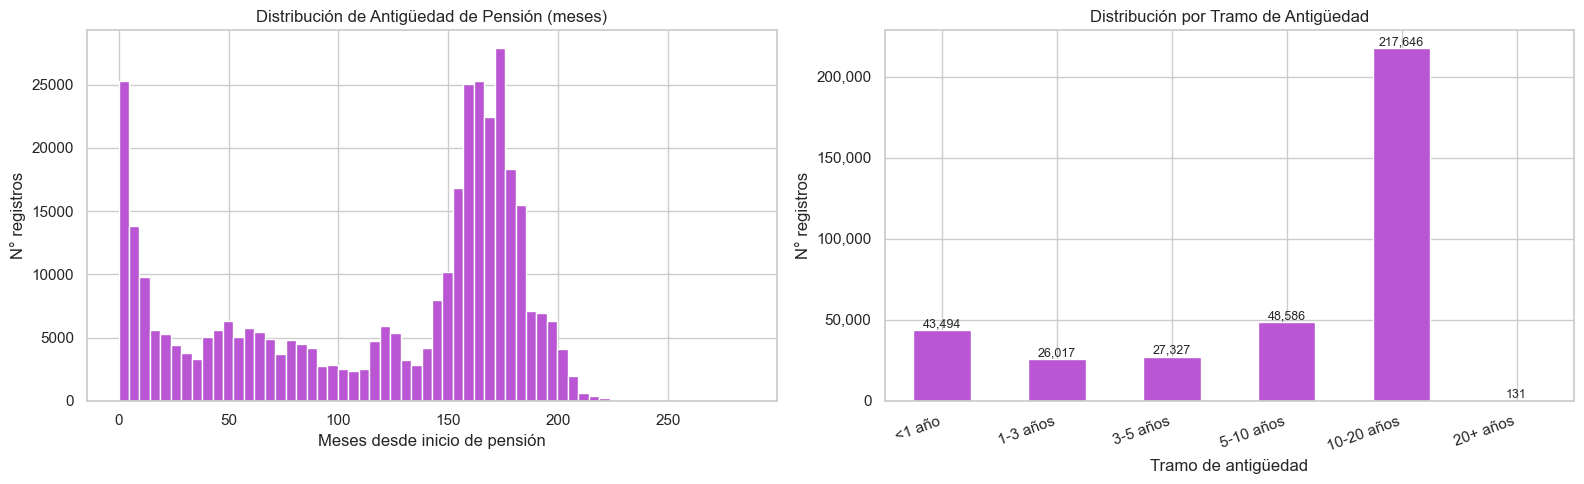

In [32]:
# Distribución de antigüedad en meses
antig = df['ANTIGUEDAD_MESES'].dropna()
antig = antig[(antig >= 0) & (antig <= 600)]

print('=== Antigüedad de Pensión (meses) ===')
print(antig.describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

antig.hist(bins=60, ax=axes[0], color='mediumorchid', edgecolor='white')
axes[0].set_title('Distribución de Antigüedad de Pensión (meses)', fontsize=12)
axes[0].set_xlabel('Meses desde inicio de pensión')
axes[0].set_ylabel('N° registros')

# Tramos de antigüedad en años
bins_ant   = [0, 12, 36, 60, 120, 240, 600]
labels_ant = ['<1 año', '1-3 años', '3-5 años', '5-10 años', '10-20 años', '20+ años']
antig_tramo = pd.cut(df['ANTIGUEDAD_MESES'], bins=bins_ant, labels=labels_ant, right=False)
antig_tramo.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='mediumorchid', edgecolor='white')
axes[1].set_title('Distribución por Tramo de Antigüedad', fontsize=12)
axes[1].set_ylabel('N° registros')
axes[1].set_xlabel('Tramo de antigüedad')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)
plt.sca(axes[1]); plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

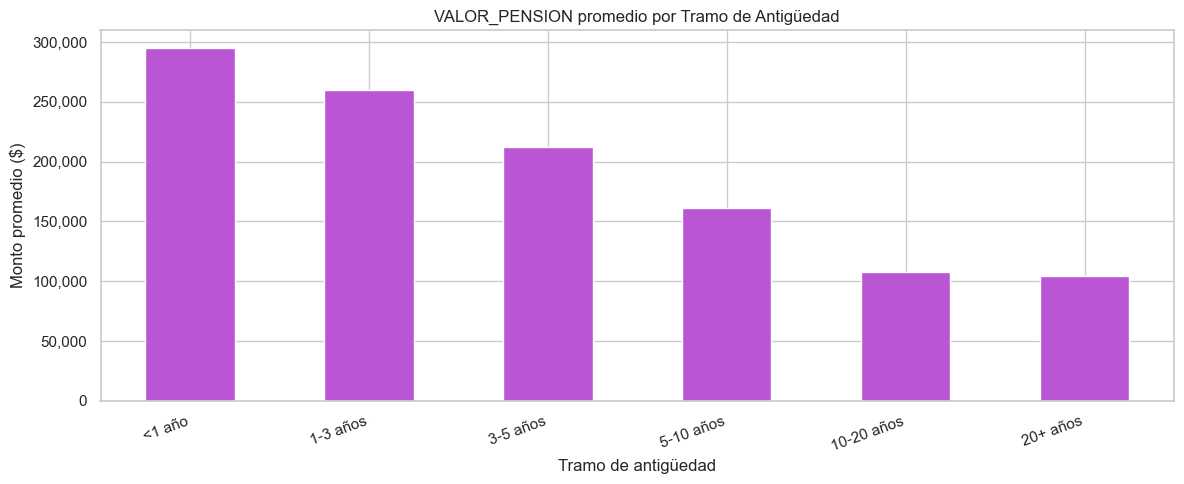

In [33]:
# VALOR_PENSION promedio por tramo de antigüedad
df['TRAMO_ANTIGUEDAD'] = pd.cut(df['ANTIGUEDAD_MESES'], bins=bins_ant, labels=labels_ant, right=False)

pension_antig = df.groupby('TRAMO_ANTIGUEDAD')[col_monto].agg(['mean', 'median', 'count'])
pension_antig.columns = ['Promedio', 'Mediana', 'N_Registros']

fig, ax = plt.subplots(figsize=(12, 5))
pension_antig['Promedio'].plot(kind='bar', ax=ax, color='mediumorchid', edgecolor='white')
ax.set_title('VALOR_PENSION promedio por Tramo de Antigüedad', fontsize=12)
ax.set_ylabel('Monto promedio ($)')
ax.set_xlabel('Tramo de antigüedad')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 13. Análisis de PGU (Pensión Garantizada Universal)

In [34]:
# Estado PGU
col_pgu = 'PGU'

pgu_counts = df[col_pgu].value_counts(dropna=False)
print('=== Distribución columna PGU ===')
display(pd.DataFrame({
    'Registros'     : pgu_counts,
    'Porcentaje (%)': (pgu_counts / len(df) * 100).round(4)
}))

=== Distribución columna PGU ===


,Registros,Porcentaje (%)
PGU,,
NaN,363202,100.0000


In [35]:
# APORTE_PGU y RENTA_PGU — análisis de quienes lo tienen informado
for col_pgu_var in ['APORTE_PGU', 'RENTA_PGU']:
    if col_pgu_var in df.columns:
        serie = df[col_pgu_var].dropna()
        if len(serie) > 0:
            print(f'\n=== {col_pgu_var} (N={len(serie):,}) ===')
            print(serie.describe().to_string())

            fig, ax = plt.subplots(figsize=(12, 4))
            serie.clip(upper=serie.quantile(0.99)).hist(bins=40, ax=ax, color='coral', edgecolor='white')
            ax.set_title(f'Distribución de {col_pgu_var} (hasta P99)', fontsize=12)
            ax.set_xlabel('Monto ($)')
            ax.set_ylabel('Frecuencia')
            ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
            plt.tight_layout()
            plt.show()
        else:
            print(f'{col_pgu_var}: sin valores informados.')

APORTE_PGU: sin valores informados.
RENTA_PGU: sin valores informados.


## 14. Análisis de CCAF y Agencia Vendedora

=== Resumen por CCAF ===


,CCAF,Registros,Afiliados_Unicos,Pension_Promedio,Pension_Mediana
7,307,"145,784","14,208","129,019.03","89,716.00"
3,303,"135,026","13,819","148,554.59","107,304.00"
2,302,"39,470","5,527","225,484.37","174,332.00"
1,301,"32,111","4,569","240,907.34","193,917.00"
5,305,"9,109",972,"119,624.01","96,390.00"
6,306,"1,608",496,"84,039.07","77,000.00"
0,0,57,9,"128,204.68","89,764.00"
4,304,36,23,"129,977.19","82,058.00"


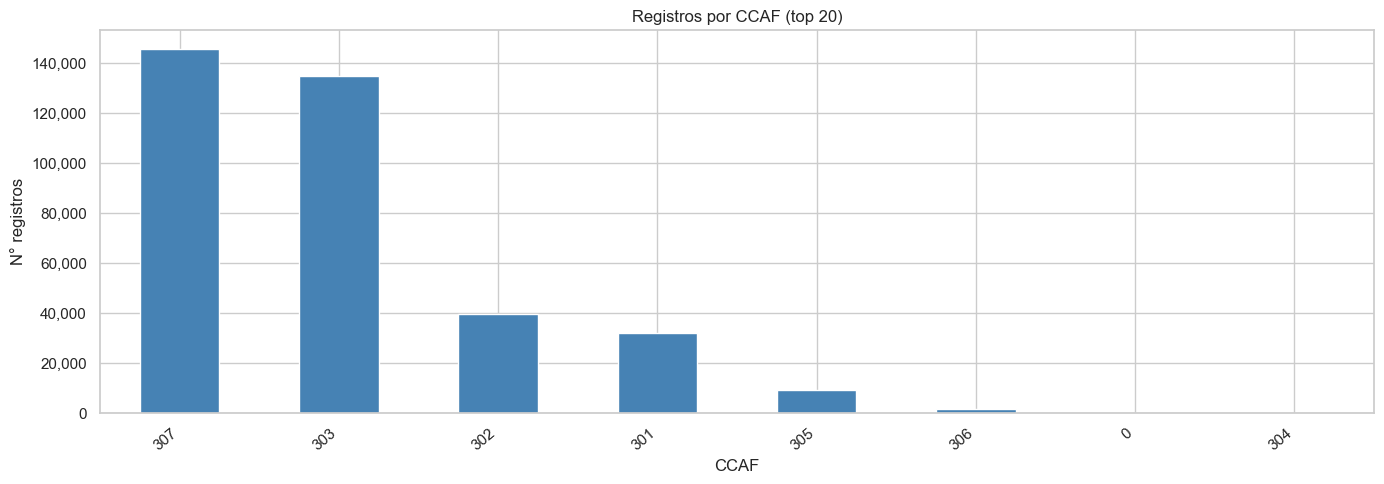

In [36]:
# Distribución por CCAF
if 'CCAF' in df.columns and df['CCAF'].notna().any():
    resumen_ccaf = df.groupby('CCAF').agg(
        Registros        =('CCAF', 'count'),
        Afiliados_Unicos =('ID_AFI', 'nunique'),
        Pension_Promedio =(col_monto, 'mean'),
        Pension_Mediana  =(col_monto, 'median'),
    ).reset_index().sort_values('Registros', ascending=False)

    print('=== Resumen por CCAF ===')
    display(resumen_ccaf.style.format({
        'Registros'        : '{:,}',
        'Afiliados_Unicos' : '{:,}',
        'Pension_Promedio' : '{:,.2f}',
        'Pension_Mediana'  : '{:,.2f}',
    }))

    fig, ax = plt.subplots(figsize=(14, 5))
    resumen_ccaf.head(20).set_index('CCAF')['Registros'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Registros por CCAF (top 20)', fontsize=12)
    ax.set_ylabel('N° registros')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

In [37]:
# AGENCIA_VEND vs AGENCIA_PENS — concordancia
if 'AGENCIA_VEND' in df.columns and 'AGENCIA_PENS' in df.columns:
    misma_agencia = (df['AGENCIA_VEND'] == df['AGENCIA_PENS']).sum()
    total_validos = df[['AGENCIA_VEND', 'AGENCIA_PENS']].dropna().shape[0]

    print(f'Registros con AGENCIA_VEND = AGENCIA_PENS: {misma_agencia:,} ({misma_agencia/total_validos*100:.2f}%)')
    print(f'Registros con agencias distintas          : {total_validos - misma_agencia:,}')

Registros con AGENCIA_VEND = AGENCIA_PENS: 155,741 (42.88%)
Registros con agencias distintas          : 207,460


## 15. Análisis de Afiliados

In [38]:
n_afiliados = df['ID_AFI'].nunique()
print(f'Afiliados únicos (pseudonimizados): {n_afiliados:,}')
print(f'Promedio de apariciones por afiliado: {len(df)/n_afiliados:.2f}')

# Cantidad de períodos en que aparece cada afiliado
periodos_afi = df.groupby('ID_AFI')['PERIODO'].nunique()
print(f'\n=== Períodos de aparición por afiliado ===')
print(periodos_afi.describe().to_string())

Afiliados únicos (pseudonimizados): 38,987
Promedio de apariciones por afiliado: 9.32

=== Períodos de aparición por afiliado ===
count   38,987.0000
mean         9.3160
std          6.3810
min          1.0000
25%          3.0000
50%          8.0000
75%         17.0000
max         18.0000


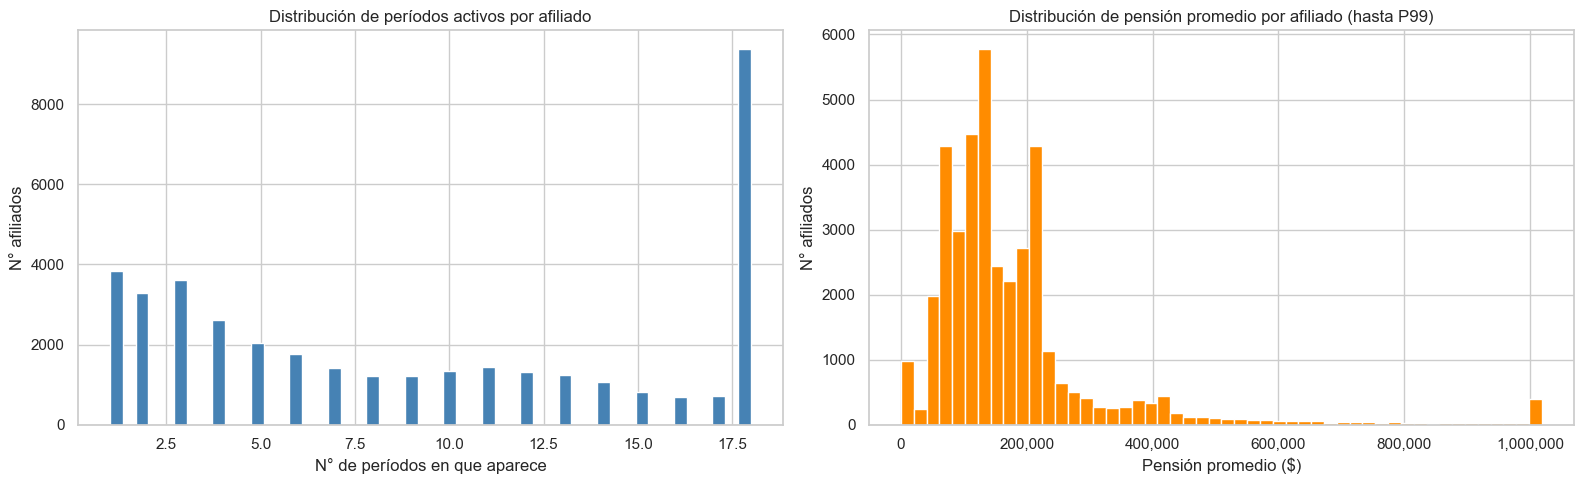

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de apariciones por afiliado
periodos_afi.hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de períodos activos por afiliado', fontsize=12)
axes[0].set_xlabel('N° de períodos en que aparece')
axes[0].set_ylabel('N° afiliados')

# VALOR_PENSION promedio por afiliado
pension_afi = df.groupby('ID_AFI')[col_monto].mean().dropna()
p99_afi = pension_afi.quantile(0.99)
pension_afi.clip(upper=p99_afi).hist(bins=50, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Distribución de pensión promedio por afiliado (hasta P99)', fontsize=12)
axes[1].set_xlabel('Pensión promedio ($)')
axes[1].set_ylabel('N° afiliados')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

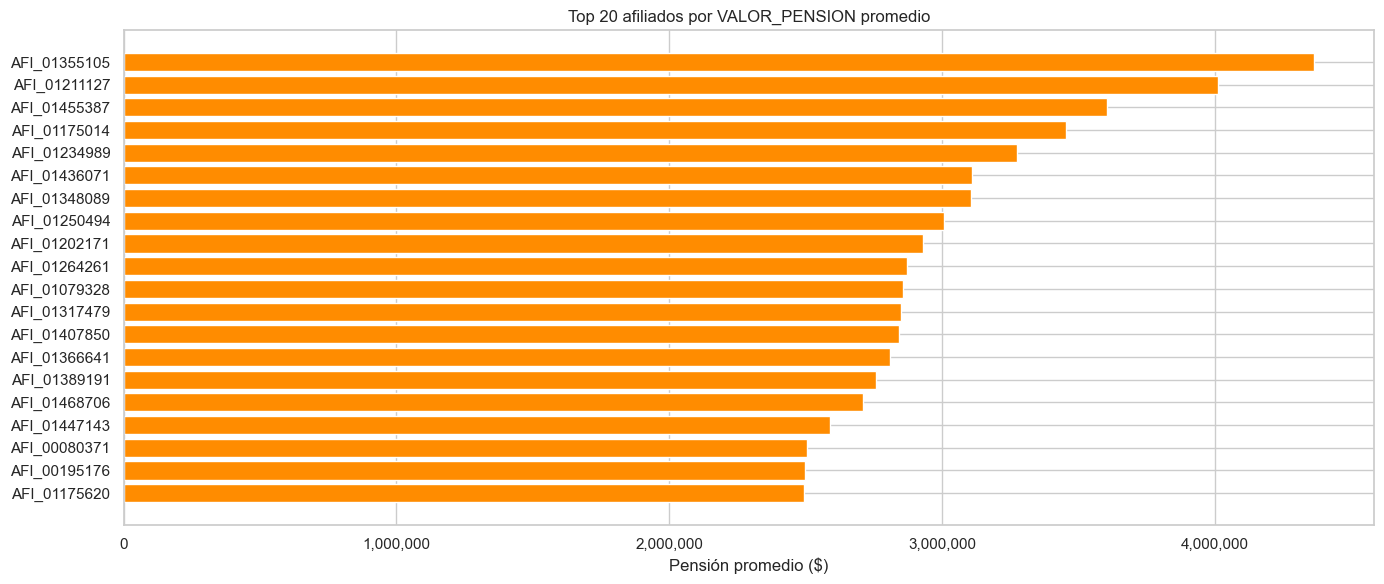

In [40]:
# Top 20 afiliados por VALOR_PENSION promedio
top20_pension = df.groupby('ID_AFI')[col_monto].mean().nlargest(20).reset_index()
top20_pension.columns = ['ID_AFI', 'Pension_Promedio']

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(top20_pension['ID_AFI'], top20_pension['Pension_Promedio'], color='darkorange', edgecolor='white')
ax.set_title('Top 20 afiliados por VALOR_PENSION promedio', fontsize=12)
ax.set_xlabel('Pensión promedio ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 16. Heatmap: Stock por Tipo de Pensión y Período

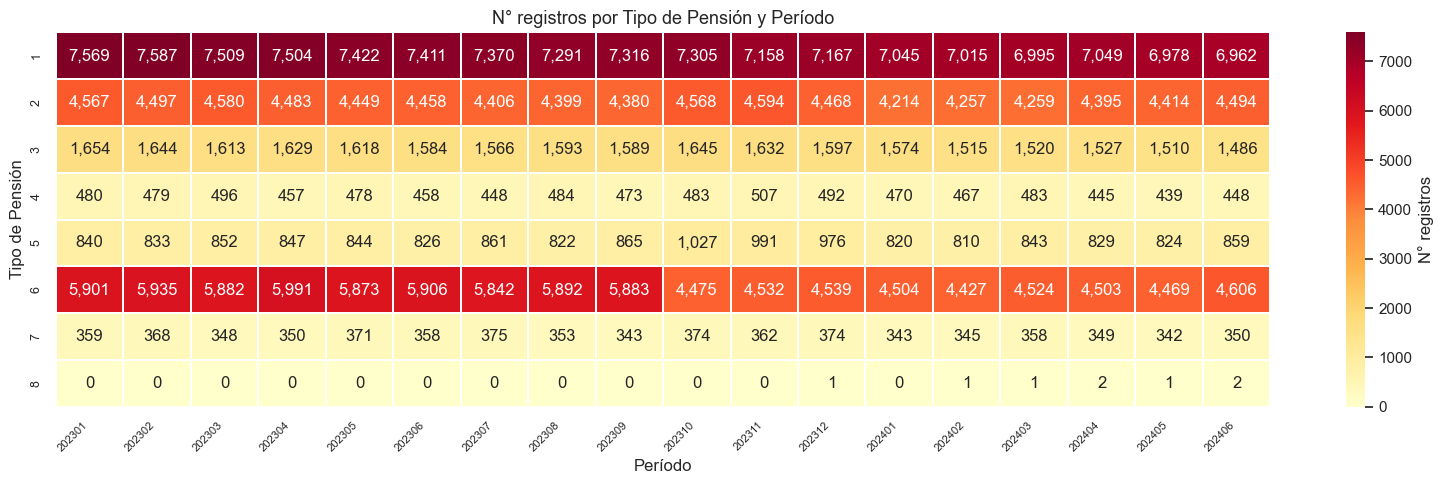

In [41]:
if 'TIPO_PENSION' in df.columns and df['TIPO_PENSION'].notna().any():
    pivot_heat = df.pivot_table(
        index='TIPO_PENSION',
        columns='PERIODO',
        values=col_monto,
        aggfunc='count',
        fill_value=0
    ).astype(int)

    anotar = pivot_heat.shape[0] * pivot_heat.shape[1] < 300
    fig, ax = plt.subplots(figsize=(max(16, pivot_heat.shape[1] * 0.6), max(5, pivot_heat.shape[0] * 0.5)))
    sns.heatmap(
        pivot_heat, cmap='YlOrRd', linewidths=0.3, ax=ax,
        annot=anotar, fmt=',d',
        cbar_kws={'label': 'N° registros'}
    )
    ax.set_title('N° registros por Tipo de Pensión y Período', fontsize=13)
    ax.set_xlabel('Período')
    ax.set_ylabel('Tipo de Pensión')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

## 17. Detección de Duplicados

In [42]:
total_dups = df.duplicated().sum()
print(f'Filas completamente duplicadas: {total_dups:,} ({total_dups/len(df)*100:.4f}%)')

# Duplicados por combinaciones clave de negocio
claves_negocio = [
    ['ID_AFI', 'PERIODO'],
    ['ID_AFI', 'PERIODO', 'TIPO_PENSION'],
    ['NUMERO_INSCRIPCION', 'PERIODO'],
]

for clave in claves_negocio:
    cols_existentes = [c for c in clave if c in df.columns]
    dups = df.duplicated(subset=cols_existentes).sum()
    print(f'Duplicados por {cols_existentes}: {dups:,} ({dups/len(df)*100:.4f}%)')

print(f'\nEjemplo de registros potencialmente duplicados (ID_AFI + PERIODO):')
clave_dup = ['ID_AFI', 'PERIODO']
dups_mask = df.duplicated(subset=clave_dup, keep=False)
display(df[dups_mask].sort_values(clave_dup).head(10))

Filas completamente duplicadas: 0 (0.0000%)
Duplicados por ['ID_AFI', 'PERIODO']: 0 (0.0000%)
Duplicados por ['ID_AFI', 'PERIODO', 'TIPO_PENSION']: 0 (0.0000%)
Duplicados por ['NUMERO_INSCRIPCION', 'PERIODO']: 0 (0.0000%)

Ejemplo de registros potencialmente duplicados (ID_AFI + PERIODO):


,PERIODO,NUMERO_INSCRIPCION,FECHA_NACMTO,POBLAC,COMUNA,CODIGO_COMUNA,AGENCIA_PENS,SEXO,ENTIDAD,NOMBRE_ENTIDAD,INDUSTRIA,PGU,APORTE_PGU,RENTA_PGU,CCAF,FECHA_INICIO,AGENCIA_VEND,TIPO_PENSION,NOMBRE_PENSION,APORTE,VALOR_PENSION,TIPO_SOLICITUD,ID_AFI,FECHA_PERIODO,EDAD,ANTIGUEDAD_MESES,TRAMO_EDAD,TRAMO_ANTIGUEDAD


## 18. Detección de Outliers

In [43]:
def detectar_outliers_iqr(serie, nombre):
    Q1    = serie.quantile(0.25)
    Q3    = serie.quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = serie[(serie < lower) | (serie > upper)]
    return {
        'Columna'        : nombre,
        'Q1'             : Q1,
        'Q3'             : Q3,
        'IQR'            : IQR,
        'Límite inferior': lower,
        'Límite superior': upper,
        'N° outliers'    : len(outliers),
        '% outliers'     : round(len(outliers) / len(serie) * 100, 2)
    }

cols_outlier = [c for c in [col_monto, 'EDAD', 'ANTIGUEDAD_MESES', 'APORTE', 'APORTE_PGU', 'RENTA_PGU']
                if c in df.columns and df[c].notna().any()]

resumen_outliers = pd.DataFrame([
    detectar_outliers_iqr(df[c].dropna(), c) for c in cols_outlier
])

print('=== Detección de Outliers (método IQR) ===')
display(resumen_outliers.set_index('Columna').style.format('{:,.2f}'))

=== Detección de Outliers (método IQR) ===


,Q1,Q3,IQR,Límite inferior,Límite superior,N° outliers,% outliers
Columna,,,,,,,
VALOR_PENSION,"75,000.00","206,200.00","131,200.00","-121,800.00","403,000.00","15,636.00",4.31
EDAD,63.00,82.00,19.00,34.50,110.50,"11,394.00",3.14
ANTIGUEDAD_MESES,55.00,170.00,115.00,-117.50,342.50,0.00,0.00


## 19. Análisis de Correlaciones

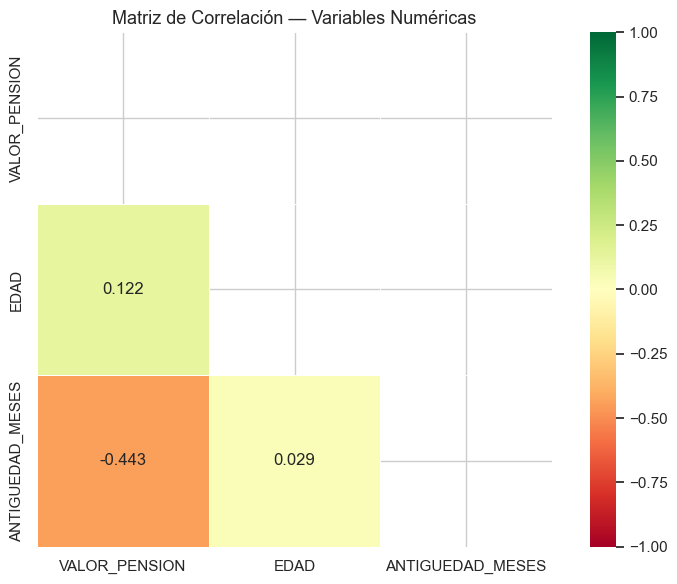

In [44]:
cols_corr = [c for c in [col_monto, 'EDAD', 'ANTIGUEDAD_MESES', 'APORTE', 'APORTE_PGU', 'RENTA_PGU']
             if c in df.columns and df[c].notna().any()]

if len(cols_corr) > 1:
    corr_matrix = df[cols_corr].corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.3f',
        cmap='RdYlGn', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5, ax=ax
    )
    ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=13)
    plt.tight_layout()
    plt.show()

## 20. Resumen Ejecutivo

In [45]:
print('=' * 68)
print('   RESUMEN EJECUTIVO — EDA VIGENTE STOCK MENSUAL PEN')
print('=' * 68)

print(f'\n[VOLUMEN]')
print(f'  Total registros      : {len(df):,}')
print(f'  Total columnas       : {df.shape[1]}')
print(f'  Rango temporal       : {df["PERIODO"].min()} → {df["PERIODO"].max()}')
print(f'  Períodos únicos      : {df["PERIODO"].nunique()}')

print(f'\n[AFILIADOS]')
print(f'  Afiliados únicos     : {df["ID_AFI"].nunique():,}')
print(f'  Prom. apariciones/afi: {len(df)/df["ID_AFI"].nunique():.2f}')

print(f'\n[DEMOGRAFÍA]')
for sexo in df['SEXO'].dropna().unique():
    n = (df['SEXO'] == sexo).sum()
    print(f'  Sexo {sexo}              : {n:,} ({n/len(df)*100:.1f}%)')
edad_v = df['EDAD'].dropna()
edad_v = edad_v[(edad_v >= 0) & (edad_v <= 120)]
print(f'  Edad promedio        : {edad_v.mean():.1f} años')
print(f'  Edad mediana         : {edad_v.median():.1f} años')

print(f'\n[PENSIÓN]')
print(f'  VALOR_PENSION promedio: ${df[col_monto].mean():>18,.2f}')
print(f'  VALOR_PENSION mediana : ${df[col_monto].median():>18,.2f}')
print(f'  VALOR_PENSION mínimo  : ${df[col_monto].min():>18,.0f}')
print(f'  VALOR_PENSION máximo  : ${df[col_monto].max():>18,.0f}')
print(f'  Tipos de pensión      : {df["TIPO_PENSION"].nunique()}')

print(f'\n[GEOGRAFÍA]')
print(f'  Comunas únicas       : {df["COMUNA"].nunique():,}')
top_com = df['COMUNA'].value_counts().index[0]
pct_com = df['COMUNA'].value_counts().iloc[0] / len(df) * 100
print(f'  Comuna más frecuente : "{top_com}" ({pct_com:.1f}%)')

print(f'\n[CALIDAD DE DATOS]')
pct_nulos = df.isnull().sum().sum() / (len(df) * df.shape[1]) * 100
print(f'  Tasa de nulidad total: {pct_nulos:.2f}%')
col_mas_nulos = nulos['Porcentaje (%)'].idxmax()
print(f'  Columna más nula     : {col_mas_nulos} ({nulos.loc[col_mas_nulos, "Porcentaje (%)"]:.1f}%)')
print(f'  Duplicados exactos   : {df.duplicated().sum():,}')

print('\n' + '=' * 68)

   RESUMEN EJECUTIVO — EDA VIGENTE STOCK MENSUAL PEN

[VOLUMEN]
  Total registros      : 363,202
  Total columnas       : 28
  Rango temporal       : 202301 → 202406
  Períodos únicos      : 18

[AFILIADOS]
  Afiliados únicos     : 38,987
  Prom. apariciones/afi: 9.32

[DEMOGRAFÍA]
  Sexo M              : 149,489 (41.2%)
  Sexo F              : 213,712 (58.8%)
  Edad promedio        : 71.1 años
  Edad mediana         : 74.0 años

[PENSIÓN]
  VALOR_PENSION promedio: $        156,222.21
  VALOR_PENSION mediana : $        112,420.00
  VALOR_PENSION mínimo  : $                 0
  VALOR_PENSION máximo  : $         4,364,315
  Tipos de pensión      : 8

[GEOGRAFÍA]
  Comunas únicas       : 309
  Comuna más frecuente : "LOS ANGELES" (3.1%)

[CALIDAD DE DATOS]
  Tasa de nulidad total: 32.14%
  Columna más nula     : NOMBRE_ENTIDAD (100.0%)
  Duplicados exactos   : 0

